In [1]:
!pip install -q --upgrade transformers accelerate bitsandbytes sentence-transformers faiss-cpu


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 83.6 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 30.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 588.7/588.7 kB 33.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 66.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 663.6/663.6 kB 34.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 85.3 MB/s eta 0:00:00:00:01


In [2]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, GenerationConfig
from sentence_transformers import SentenceTransformer
import faiss, numpy as np
print("torch:", torch.__version__, "cuda available:", torch.cuda.is_available())
!nvidia-smi -L


torch: 2.10.0+cu128 cuda available: True
GPU 0: Tesla T4 (UUID: GPU-d9de6a64-5dff-ca7c-d00d-f316bd2dd53e)
GPU 1: Tesla T4 (UUID: GPU-f699d396-18a9-b640-3ce8-4c7b60fcc400)


In [ ]:
from datasets import load_dataset
import pandas as pd

pubmed = load_dataset("pubmed_qa","pqa_labeled", split="train")
print("Columns:", pubmed.column_names)
pubmed_df = pubmed.to_pandas()
# keep question and context (doc); rename answer column if present
if 'answer' in pubmed_df.columns:
    pubmed_df = pubmed_df[['question','context','answer']].rename(columns={'context':'doc','answer':'gold_answer'})
else:
    pubmed_df = pubmed_df[['question','context']].rename(columns={'context':'doc'})
pubmed_df.head()


In [ ]:
from datasets import load_dataset

# Load the 'pqa_labeled' split: 1,000 high-quality, human-annotated samples.
medhallu_labeled = load_dataset("UTAustin-AIHealth/MedHallu", "pqa_labeled")

# Load the 'pqa_artificial' split: 9,000 samples generated via an automated pipeline.
medhallu_artificial = load_dataset("UTAustin-AIHealth/MedHallu", "pqa_artificial")


In [3]:
import os, random
import numpy as np
import pandas as pd
from datasets import load_dataset, Dataset
from tqdm.auto import tqdm
random.seed(42); np.random.seed(42)

In [4]:
import json, os, math, time
import numpy as np
from sentence_transformers import SentenceTransformer
from tqdm.auto import tqdm
import faiss
DEVICE = "cuda" if __import__('torch').cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cuda


In [5]:
# load the prepared corpus chunks written earlier
corpus = []
with open('/kaggle/input/datasets/adityamodi20/thesis/corpus_chunks.jsonl','r',encoding='utf-8') as f:
    for line in f:
        corpus.append(json.loads(line))
print("Loaded corpus chunks:", len(corpus))
texts = [c['text'] for c in corpus]


Loaded corpus chunks: 292965


In [6]:
embed_model_name = "NeuML/pubmedbert-base-embeddings"
embed_model = SentenceTransformer(embed_model_name, device=DEVICE)

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/667 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/74.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [7]:
# Test with Option B first
embed_model_name = "NeuML/pubmedbert-base-embeddings"
embed_model = SentenceTransformer(embed_model_name, device=DEVICE)

batch_size = 512  # Can go higher with smaller models
emb_list = []
start = time.time()

for i in tqdm(range(0, len(texts), batch_size)):
    batch = texts[i:i+batch_size]
    emb = embed_model.encode(
        batch, 
        convert_to_numpy=True, 
        show_progress_bar=False,
        normalize_embeddings=True
    )
    emb_list.append(emb)

embeddings = np.vstack(emb_list).astype('float32')
print("Emb shape:", embeddings.shape, "time(s):", time.time()-start)


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/667 [00:00<?, ?B/s]

...

added_tokens.json:   0%|          | 0.00/74.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

  0%|          | 0/573 [00:00<?, ?it/s]

Emb shape: (292965, 768) time(s): 6863.095963001251


In [8]:
import numpy as np
np.save("embeddings.npy", embeddings)
# load: embeddings = np.load("embeddings.npy")


In [9]:
ids = list(range(len(texts)))
import json
with open("ids.json","w") as f:
    json.dump(ids, f)
np.save("embeddings.npy", embeddings)


In [10]:
import faiss
d = embeddings.shape[1]
index = faiss.IndexFlatIP(d)            # inner-product (use IndexFlatL2 for L2)
index.add(embeddings)                   # add vectors
faiss.write_index(index, "embeddings.faiss")
# load: index = faiss.read_index("embeddings.faiss")


In [ ]:
import faiss
d = embeddings.shape[1]
index = faiss.IndexFlatIP(d)            # inner-product (use IndexFlatL2 for L2)
index.add(embeddings)                   # add vectors
faiss.write_index(index, "embeddings.faiss")
# load: index = faiss.read_index("embeddings.faiss")


In [7]:
import shutil, os
src = "/kaggle/input/datasets/adityamodi20/thesis/corpus_meta.jsonl"
dst = "/kaggle/working/corpus_meta.jsonl"
shutil.copyfile(src, dst)
# then modify dst


import shutil, os
src = "/kaggle/input/models/adityamodi20/embedings/transformers/default/1/embeddings.faiss"
dst = "/kaggle/working/embeddings.faiss"
shutil.copyfile(src, dst)
# then modify dst

'/kaggle/working/embeddings.faiss'

In [8]:
embeddings = np.load("/kaggle/input/models/adityamodi20/embedings/transformers/default/1/embeddings(1).npy")  # or .npz, .pt, etc.

In [9]:
# L2 normalize for cosine-sim using inner-product search
faiss.normalize_L2(embeddings)

d = embeddings.shape[1]
# For moderate corpus sizes, IndexFlatIP is fine. For large corpora consider IVF+PQ.
index = faiss.IndexFlatIP(d)
index.add(embeddings)
print("Index size:", index.ntotal)
# Save index and metadata
faiss.write_index(index, "/kaggle/working/embeddings.faiss")
# Save metadata (corpus mapping)
with open("/kaggle/working/corpus_meta.jsonl","w",encoding="utf-8") as f:
    for c in corpus:
        f.write(json.dumps(c, ensure_ascii=False) + "\n")
print("Saved index and metadata")

Index size: 292965
Saved index and metadata


In [9]:
!pip install rank_bm25

In [10]:
import json
import ast
import faiss
from rank_bm25 import BM25Okapi
import numpy as np

# =========================
# Load your corpus_meta.jsonl
# =========================
corpus_file = "/kaggle/working/corpus_meta.jsonl"
corpus = []
with open(corpus_file, "r", encoding="utf-8") as f:
    for line in f:
        corpus.append(json.loads(line))

# =========================
# Prepare text for BM25
# =========================
text_corpus = []
for doc in corpus:
    try:
        # Convert the 'text' string (list-like) into actual list
        sentences = ast.literal_eval(doc['text'])
        full_text = " ".join(sentences)
        text_corpus.append(full_text)
    except:
        text_corpus.append(doc['text'])

# Tokenize for BM25
tokenized_corpus = [doc.lower().split() for doc in text_corpus]
bm25 = BM25Okapi(tokenized_corpus)
print("BM25 index built.")

# =========================
# Prepare FAISS
# =========================
# Assuming you already have embeddings for each doc (NumPy array)
# embeddings = np.array([...]) shape = (num_docs, embedding_dim)

# Normalize for cosine similarity
faiss.normalize_L2(embeddings)

d = embeddings.shape[1]
index = faiss.IndexFlatIP(d)  # inner product = cosine if normalized
index.add(embeddings)
print("FAISS index built. Total vectors:", index.ntotal)

# =========================
# Example hybrid retrieval
# =========================
def hybrid_search(query, top_k=5, bm25_weight=0.45, faiss_weight=0.55):
    # ---- BM25 ----
    query_tokens = query.lower().split()
    bm25_scores = bm25.get_scores(query_tokens)
    bm25_top_idx = np.argsort(-bm25_scores)[:top_k]

    # ---- FAISS ----
    # Assuming you have a model to convert query -> embedding
    # query_embedding = get_embedding(query)
    faiss.normalize_L2(query_embedding)
    D, I = index.search(query_embedding.reshape(1, -1), top_k)
    faiss_top_idx = I[0]

    # ---- Combine results (simple merge) ----
    hybrid_idx = list(dict.fromkeys(list(faiss_top_idx) + list(bm25_top_idx)))
    results = [corpus[i] for i in hybrid_idx[:top_k]]
    return results

# =========================
# Test search
# =========================
query = "microRNA pancreatic islet genesis"
# query_embedding = your_embedding_model.encode(query)  # NumPy array
# results = hybrid_search(query, top_k=5)
# for r in results:
#     print(r['doc_id'], r['title'])

<unknown>:1: SyntaxWarning: invalid decimal literal


BM25 index built.
FAISS index built. Total vectors: 292965


In [57]:
import json
import faiss
import numpy as np
from rank_bm25 import BM25Okapi

# ===============================
# 1. Load corpus
# ===============================
corpus_path = "/kaggle/working/corpus_meta.jsonl"
corpus = []
texts = []  # for BM25
with open(corpus_path, "r", encoding="utf-8") as f:
    for line in f:
        doc = json.loads(line)
        corpus.append(doc)
        # Use only the "text" field for BM25
        # Flatten list if text is a string representation of a list
        text_content = doc["text"]
        if isinstance(text_content, str) and text_content.startswith("[") and text_content.endswith("]"):
            text_content = text_content.replace("'", "").replace("[", "").replace("]", "")
        texts.append(text_content)

# ===============================
# 2. Build BM25 index
# ===============================
tokenized_corpus = [doc.lower().split() for doc in texts]
bm25 = BM25Okapi(tokenized_corpus)
print("BM25 index built.")

# ===============================
# 3. Load FAISS index
# ===============================
faiss_index_path = "/kaggle/working/embeddings.faiss"
index = faiss.read_index(faiss_index_path)
print("FAISS index loaded:", index.ntotal)

# ===============================
# 4. Define hybrid retrieval function
# ===============================
def hybrid_retrieve(query, top_k=5, bm25_weight=0.5, faiss_weight=0.7):
    """
    Retrieve top_k documents using a hybrid of BM25 + FAISS scores.
    """
    # -------- BM25 retrieval --------
    query_tokens = query.lower().split()
    bm25_scores = bm25.get_scores(query_tokens)
    bm25_ranks = np.argsort(-bm25_scores)
    
    # Normalize BM25 scores to [0,1]
    if np.max(bm25_scores) > 0:
        bm25_scores_norm = bm25_scores / np.max(bm25_scores)
    else:
        bm25_scores_norm = bm25_scores

    # -------- FAISS retrieval --------
    # Encode query with your embedding model (assume PubMedBERT embeddings are preloaded)
    query_embedding = get_embedding(query)  # <-- implement this with your model
    query_embedding = np.array([query_embedding]).astype("float32")
    faiss.normalize_L2(query_embedding)
    D, I = index.search(query_embedding, top_k*2)  # retrieve more to merge later
    faiss_scores = D[0]
    faiss_ranks = I[0]

    # Normalize FAISS scores to [0,1]
    if np.max(faiss_scores) > 0:
        faiss_scores_norm = faiss_scores / np.max(faiss_scores)
    else:
        faiss_scores_norm = faiss_scores

    # -------- Combine scores --------
    combined_dict = {}
    # Add BM25 scores
    for i, score in enumerate(bm25_scores_norm):
        combined_dict[i] = bm25_weight * score
    # Add FAISS scores
    for i, score in zip(faiss_ranks, faiss_scores_norm):
        if i in combined_dict:
            combined_dict[i] += faiss_weight * score
        else:
            combined_dict[i] = faiss_weight * score

    # Sort by combined score
    sorted_docs = sorted(combined_dict.items(), key=lambda x: -x[1])
    
    # Deduplicate and return top_k
    results = []
    seen_texts = set()
    for idx, score in sorted_docs:
        doc_text = texts[idx]
        if doc_text not in seen_texts:
            results.append({
                "doc": corpus[idx],
                "score": float(score)
            })
            seen_texts.add(doc_text)
        if len(results) >= top_k:
            break
    
    return results

# ===============================
# 5. Example usage
# ===============================
query = "Is microRNA expression required for pancreatic islet cell genesis in the mouse?"
top_docs = hybrid_retrieve(query, top_k=5)
for i, d in enumerate(top_docs):
    print(f"\nRank {i+1}, Score: {d['score']:.4f}")
    print("Title:", d['doc']['title'])
    print("Text:", d['doc']['text'][:300], "...")  # preview first 300 chars

BM25 index built.
FAISS index loaded: 292965


NameError: name 'get_embedding' is not defined

In [11]:
import json

file_path = "/kaggle/working/corpus_meta.jsonl"

# Read all documents
with open(file_path, "r", encoding="utf-8") as f:
    corpus = [json.loads(line) for line in f]

# View the first 3 documents
for doc in corpus[:3]:
    print(json.dumps(doc, indent=2, ensure_ascii=False))

{
  "doc_id": "med_3771",
  "chunk_id": "med_3771_0",
  "title": "MedHallu",
  "text": "['Up-regulated expression of syndecan-1, a member of the transmembranous proteoglycans that serves as a co-receptor for a wide pool of extracellular ligands, has been ascribed to the promotion of growth of various cancers including breast, ovarian, and endometrial cancers. Here, we have extended these observations to gain insight into correlation between the expression level of syndecan-1 and its tumor-promoting characteristics, particularly, cancer invasion, in endometrial cancer.' 'Human syndecan-1 was stably transfected into three human endometrial cancer cell lines, and its effects were examined with respect to cell survival/proliferation and invasion. In addition, the activation of underlying signaling components, including integrins, focal adhesion kinase (FAK), and nuclear factor kappaB (NF-kappaB) was examined. The activity of NF-kappaB as a transcription factor for matrix metalloproteinase 

In [12]:
!pip install rank_bm25

In [13]:
from pprint import pprint
# simple retrieval function using index and the same embed_model
import re

def preprocess_medical_query(query):
    # Normalize spacing
    query = ' '.join(query.split())
    # Keep domain terms intact (don't lowercase aggressively)
    query = query.strip()
    return query


def retrieve_top_k(query, k=100):
    query = preprocess_medical_query(query)
    q_emb = embed_model.encode(query, convert_to_numpy=True).astype('float32')
    faiss.normalize_L2(q_emb.reshape(1,-1))
    scores, ids = index.search(q_emb.reshape(1,-1), k)
    ids = ids[0].tolist()
    scores = scores[0].tolist()
    results = []
    for sc, idx in zip(scores, ids):
        meta = corpus[idx]
        results.append({'score': float(sc), 'doc_id': meta['doc_id'], 'chunk_id': meta['chunk_id'], 'title': meta['title'], 'text': meta['text']})
    return results

# quick test
q = "What are common side effects of aspirin?"
pprint(retrieve_top_k(q, k=10))

[{'chunk_id': 'pubmed_114014_1',
  'doc_id': 'pubmed_114014',
  'score': 0.6062519550323486,
  'text': "'Drug-Related Side Effects and Adverse Reactions', 'Female', "
          "'Humans', 'Incidence', 'Iodine', 'Kidney Diseases', 'Male', "
          "'Massachusetts', 'Risk Assessment', 'Risk Factors', 'Stroke', "
          "'Tomography, X-Ray Computed']}",
  'title': 'PubMed'},
 {'chunk_id': 'pubmed_19018_1',
  'doc_id': 'pubmed_19018',
  'score': 0.5578710436820984,
  'text': '> 3) were found for Adverse effect medicinal and biological '
          'substance not elsewhere classified, Unspecified adverse effect drug '
          'properly administered, Idiopathic fibrosing alveolitis, '
          'Osteomyelitis, Immune deficiency, Elevated sedimentation rate, '
          'Tuberculin test reaction abnormal or positive, Anemia and Cushing '
          "syndrome.'], 'labels': ['BACKGROUND', 'METHODS', 'RESULTS'], "
          "'meshes': ['Adolescent', 'Adult', 'Aged', 'Aged, 80 and over', "


In [14]:
import os, time, json
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, GenerationConfig
from tqdm.auto import tqdm
import faiss
from sentence_transformers import SentenceTransformer
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cuda


In [15]:
# corpus metadata and faiss index
corpus = [json.loads(l) for l in open('/kaggle/working/corpus_meta.jsonl','r',encoding='utf-8')]
index = faiss.read_index("/kaggle/working/embeddings.faiss")

# load test splits
import pandas as pd
med_test = pd.read_parquet('/kaggle/input/datasets/adityamodi20/thesis/med_test.parquet')
pubmed_test = pd.read_parquet('/kaggle/input/datasets/adityamodi20/thesis/pubmed_test.parquet')

# combine or evaluate separately
test_df = pd.concat([med_test, pubmed_test], ignore_index=True).reset_index(drop=True)
print("Total test samples:", len(test_df))


Total test samples: 33191


In [16]:
from sentence_transformers import CrossEncoder

reranker = CrossEncoder('tomaarsen/reranker-PubMedBERT-base-MIRIAD-150k')
# or for medical: 'cross-encoder/qnli-distilroberta-base'

def retrieve(query, k=150, rerank_k=50):
    # Get top-50 from FAISS
    results = retrieve_top_k(query, k=k)
    
    # Rerank top-k
    texts_to_score = [r['text'] for r in results[:rerank_k]]
    scores = reranker.predict([[query, text] for text in texts_to_score])
    
    # Sort by rerank score
    reranked = sorted(
        zip(scores, results[:rerank_k]), 
        key=lambda x: x[0], 
        reverse=True
    )
    
    return [{'score': float(s), **r} for s, r in reranked]


modules.json:   0%|          | 0.00/138 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/276 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/234 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/802 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/366 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [17]:
# Before running full RAG, check retrieval quality
def eval_retrieval(test_df, k=50):
    hit_count = 0
    mrr_sum = 0
    
    for _, row in test_df.iterrows():
        results = retrieve_top_k(row['question'], k=k)
        retrieved_ids = [r['doc_id'] for r in results]
        
        # Check if any retrieved doc is relevant
        if row['id'] in retrieved_ids:
            rank = retrieved_ids.index(row['id']) + 1
            hit_count += 1
            mrr_sum += 1 / rank
    
    recall = hit_count / len(test_df)
    mrr = mrr_sum / len(test_df)
    print(f"Recall@{k}: {recall:.3f}, MRR: {mrr:.3f}")

eval_retrieval(med_test, k=200)
#eval_retrieval(pubmed_test, k=5)

Recall@200: 0.998, MRR: 0.822


In [ ]:
eval_retrieval(pubmed_test, k=2)

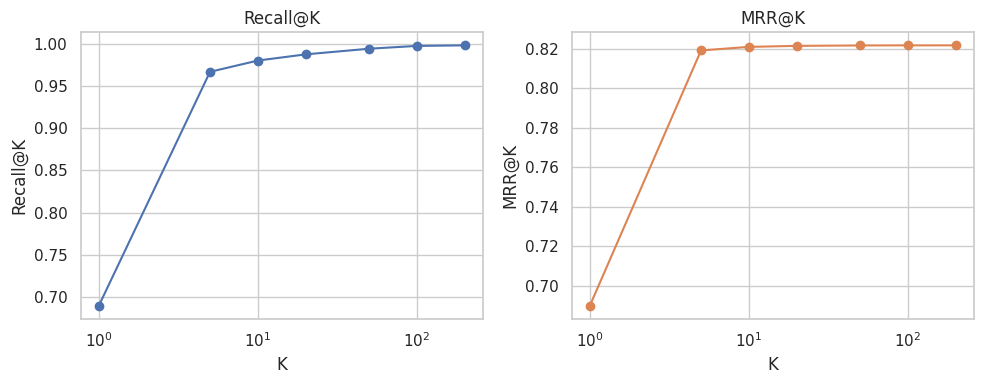

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

def eval_retrieval_metrics(test_df, ks=(1,5,10,20,50,100,200)):
    recall_list = []
    mrr_list = []
    for k in ks:
        hit_count = 0
        mrr_sum = 0.0
        for _, row in test_df.iterrows():
            results = retrieve_top_k(row['question'], k=k)
            retrieved_ids = [r['doc_id'] for r in results]
            if row['id'] in retrieved_ids:
                rank = retrieved_ids.index(row['id']) + 1
                hit_count += 1
                mrr_sum += 1.0 / rank
        recall_list.append(hit_count / len(test_df))
        mrr_list.append(mrr_sum / len(test_df))
    return np.array(ks), np.array(recall_list), np.array(mrr_list)

ks, recalls, mrrs = eval_retrieval_metrics(med_test, ks=(1,5,10,20,50,100,200))

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(ks, recalls, marker='o')
plt.xscale('log' if max(ks)/min(ks) > 10 else 'linear')
plt.xlabel('K')
plt.ylabel('Recall@K')
plt.title('Recall@K')
plt.subplot(1,2,2)
plt.plot(ks, mrrs, marker='o', color='C1')
plt.xscale('log' if max(ks)/min(ks) > 10 else 'linear')
plt.xlabel('K')
plt.ylabel('MRR@K')
plt.title('MRR@K')
plt.tight_layout()
plt.show()


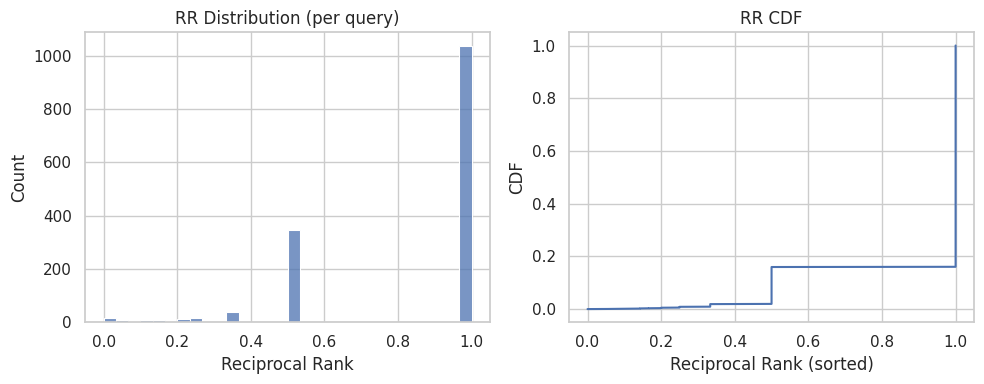

In [25]:
def compute_rrs(test_df, k=200):
    rrs = []
    for _, row in test_df.iterrows():
        results = retrieve_top_k(row['question'], k=k)
        retrieved_ids = [r['doc_id'] for r in results]
        if row['id'] in retrieved_ids:
            rank = retrieved_ids.index(row['id']) + 1
            rrs.append(1.0 / rank)
        else:
            rrs.append(0.0)
    return np.array(rrs)

rrs = compute_rrs(med_test, k=200)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.histplot(rrs, bins=30, kde=False)
plt.xlabel('Reciprocal Rank')
plt.title('RR Distribution (per query)')
plt.subplot(1,2,2)
sorted_rrs = np.sort(rrs)
cdf = np.cumsum(sorted_rrs) / np.sum(sorted_rrs) if sorted_rrs.sum()>0 else np.cumsum(sorted_rrs)/len(sorted_rrs)
plt.plot(sorted_rrs, cdf)
plt.xlabel('Reciprocal Rank (sorted)')
plt.ylabel('CDF')
plt.title('RR CDF')
plt.tight_layout()
plt.show()


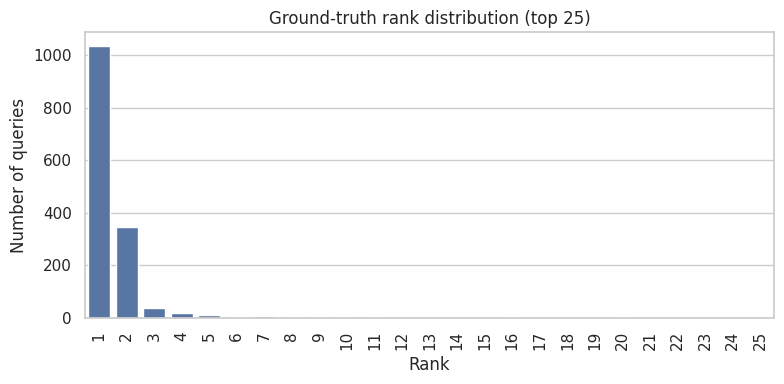

In [28]:
def rank_histogram(test_df, K=25):
    counts = np.zeros(K+1, dtype=int)  # index 0 for not found
    for _, row in test_df.iterrows():
        results = retrieve_top_k(row['question'], k=K)
        retrieved_ids = [r['doc_id'] for r in results]
        if row['id'] in retrieved_ids:
            rank = retrieved_ids.index(row['id']) + 1
            counts[rank] += 1
        else:
            counts[0] += 1
    return counts

K = 25
counts = rank_histogram(med_test, K=K)

plt.figure(figsize=(8,4))
sns.barplot(x=list(range(1,K+1)), y=counts[1:], color='C0')
plt.xlabel('Rank')
plt.ylabel('Number of queries')
plt.title(f'Ground-truth rank distribution (top {K})')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


In [18]:
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline, TextStreamer
import torch


base_model = "/kaggle/input/models/metaresearch/llama-3.2/transformers/3b/1"

tokenizer = AutoTokenizer.from_pretrained(base_model)

model = AutoModelForCausalLM.from_pretrained(
    base_model,
    return_dict=True,
    low_cpu_mem_usage=True,
    torch_dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True,
)
model.eval()

print("model loaded")
gen_config = GenerationConfig(temperature=0.0, top_p=0.95, max_new_tokens=256)


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

[transformers] The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


model loaded


In [19]:
from transformers import AutoTokenizer, AutoModelForCausalLM, GenerationConfig
import torch
import torch
import gc
# Initialize model and tokenizer (you already have this)
base_model = "/kaggle/input/models/metaresearch/llama-3.2/transformers/3b/1"
tokenizer = AutoTokenizer.from_pretrained(base_model)
model = AutoModelForCausalLM.from_pretrained(
    base_model,
    return_dict=True,
    low_cpu_mem_usage=True,
    torch_dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True,
)
model.eval()

gen_config = GenerationConfig(
    temperature=0.7,  # Changed from 0.0
    top_p=0.95, 
    max_new_tokens=512,
    do_sample=True,  # Keep this for sampling-based generation
    pad_token_id=tokenizer.eos_token_id,
)

def baseline_answer(question):
    """Generate answer using only the LLM, no retrieval"""

    # Clear GPU cache before generation
    torch.cuda.empty_cache()
    gc.collect()
    
    prompt = f"""Answer the following medical/scientific question concisely and accurately.

Question: {question}

Answer:"""
    
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512)
    
    # FIX: Move inputs to same device as model
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            generation_config=gen_config,
        )
    
    full_response = tokenizer.decode(outputs[0], skip_special_tokens=True)
    answer = full_response.replace(prompt, "").strip()
    return answer

def rag_answer(question, retrieved_docs, k=5):
    """Generate answer using retrieved documents as context"""
    # Clear GPU cache before generation
    torch.cuda.empty_cache()
    gc.collect()
    
    # Format retrieved documents as clean text (NOT raw dicts)
    context_parts = []
    for i, doc in enumerate(retrieved_docs[:k]):
        # Extract text content properly
        text_content = doc.get('text', '')
        title = doc.get('title', 'Unknown')
        
        # If text is a dict with 'contexts', join them
        if isinstance(text_content, dict) and 'contexts' in text_content:
            text_content = ' '.join(text_content['contexts'])
        
        if text_content:  # Only add if there's actual content
            context_parts.append(f"Document {i+1}: {text_content[:500]}")  # Limit to 500 chars per doc
    
    context_text = "\n\n".join(context_parts)
    
    # Truncate context if too long
    max_context_length = 800
    if len(context_text) > max_context_length:
        context_text = context_text[:max_context_length] + "..."
    
    # Create cleaner RAG prompt
    prompt = f"""

You are a highly knowledgeable medical question-answering assistant.

Instructions:
1. Answer the question using ONLY the information provided in the context below.
2. Do NOT use your own knowledge or make assumptions.
3. If the answer is not present in the context, respond exactly: "Not found in provided documents."
4. Provide concise, factual answers. Do NOT add explanations unless explicitly asked.

    "

Context:
{context_text}

Question: {question}

Answer:"""
    
    print(f"\n[RAG PROMPT LENGTH: {len(prompt)} chars]")  # Debug info
    
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=2048)
    
    # FIX: Move inputs to same device as model
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            generation_config=gen_config,
        )
    
    full_response = tokenizer.decode(outputs[0], skip_special_tokens=True)
    answer = full_response.replace(prompt, "").strip()
    return answer

# ===== COMPARISON FUNCTION =====
def compare_on_question(question, k=5):
    """Run both baseline and RAG on the same question"""
    print(f"\n{'='*80}")
    print(f"QUESTION: {question}")
    print(f"{'='*80}")
    
    # Baseline
    print("\n[BASELINE LLM]")
    baseline_resp = baseline_answer(question)
    print(baseline_resp)
    
    # Retrieve context
    print(f"\n[RAG - RETRIEVING DOCUMENTS]")
    retrieved = retrieve(question, k=100, rerank_k=50)  # Your retrieval function
    print(f"Retrieved {len(retrieved)} documents")
    for i, doc in enumerate(retrieved[:3]):
        print(f"  {i+1}. {doc['title']} (score: {doc['score']:.4f})")
    
    # RAG answer
    print(f"\n[RAG LLM WITH CONTEXT]")
    rag_resp = rag_answer(question, retrieved, k=k)
    print(rag_resp)
    
    return {
        'question': question,
        'baseline': baseline_resp,
        'rag': rag_resp,
        'retrieved_docs': retrieved[:k]
    }

# ===== TEST ON YOUR QUESTIONS =====
test_questions = [
    "Is microRNA expression required for pancreatic islet cell genesis in the mouse?",
    "Are dietary Fat and Fiber Intakes Associated with Patterns of Urinary Estrogen Metabolites in Premenopausal Women?",
    "Does magnetic resonance fluoroscopy allow targeted delivery of mesenchymal stem cells to infarct borders in Swine?",
]

results = []
for q in test_questions:
    result = compare_on_question(q, k=10)
    results.append(result)


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]


QUESTION: Is microRNA expression required for pancreatic islet cell genesis in the mouse?

[BASELINE LLM]


[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


No. MicroRNAs are not required for pancreatic islet cell genesis in the mouse.

Explanation: Pancreatic islet cells are composed of endocrine cells, which are responsible for secretion of hormones. These cells are derived from a progenitor population called the pancreatic progenitor cell (PPC). PPCs are capable of differentiation into pancreatic islet cells in vitro. A number of microRNAs have been shown to regulate PPC development, such as miR-17, miR-15, miR-16, miR-34, and miR-125a. However, there is no evidence that microRNAs are required for PPC development in vivo.

The development of pancreatic islets in mice follows a well-defined program of differentiation. The initial step is the formation of the pancreatic bud, which is a structure that projects from the embryonic foregut. This bud is then further differentiated into the pancreas, which is composed of two main regions: the endocrine pancreas and the exocrine pancreas. The endocrine pancreas is responsible for the production 

In [20]:
!pip install bert_score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 2.4 MB/s eta 0:00:00


In [21]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, f1_score
from bert_score import score as bertscore
from rouge_score import rouge_scorer
from tqdm import tqdm

# Normalize answers for yes/no/maybe or short answers
def normalize_answer(text):
    text = str(text).lower().strip()
    if 'yes' in text:
        return 'yes'
    elif 'no' in text:
        return 'no'
    else:
        return text  # keep original for MedHallu long answers

In [22]:
def hallucination_score(answer, retrieved_docs):
    """
    Simple faithfulness metric:
    % of answer sentences that appear in retrieved docs context.
    """
    context = " ".join([d.get("text", "") for d in retrieved_docs]).lower()
    answer_sentences = [s.strip() for s in answer.lower().split(".") if len(s.strip()) > 10]

    if not answer_sentences:
        return 0.0

    supported = sum(1 for s in answer_sentences if s in context)
    hallucination_rate = 1 - (supported / len(answer_sentences))
    return hallucination_rate

In [23]:
def recall_at_k(retrieved_docs, gold_doc_ids, k=5):
    retrieved_ids = [d['doc_id'] for d in retrieved_docs[:k]]
    hits = len(set(retrieved_ids) & set(gold_doc_ids))
    return hits / len(gold_doc_ids)

In [24]:
def evaluate_dataset(dataset, k_retrieval=10, rerank_k=20):
    """
    dataset: list of dicts with keys: question, answer, context, doc_id (for MedHallu/PubMedQA)
    """
    results = []

    for sample in tqdm(dataset):
        question = sample['question']
        ground_truth = sample['answer']
        gold_context_ids = [sample.get('doc_id')] if 'doc_id' in sample else []

        # Baseline prediction
        baseline_pred = baseline_answer(question)

        # RAG prediction
        retrieved_docs = retrieve(question, k=k_retrieval, rerank_k=rerank_k)
        rag_pred = rag_answer(question, retrieved_docs, k=k_retrieval)

        # Compute hallucination
        baseline_halluc = hallucination_score(baseline_pred, retrieved_docs)
        rag_halluc = hallucination_score(rag_pred, retrieved_docs)

        # Compute retrieval Recall@K
        if gold_context_ids:
            rec_at_k = recall_at_k(retrieved_docs, gold_context_ids, k=k_retrieval)
        else:
            rec_at_k = np.nan

        results.append({
            'question': question,
            'ground_truth': ground_truth,
            'baseline_prediction': baseline_pred,
            'rag_prediction': rag_pred,
            'baseline_hallucination': baseline_halluc,
            'rag_hallucination': rag_halluc,
            'retrieval_recall_at_k': rec_at_k,
            'retrieved_docs': retrieved_docs
        })

    return pd.DataFrame(results)

In [25]:
def compute_metrics(df, use_normalization=True):
    gt = df['ground_truth'].apply(normalize_answer) if use_normalization else df['ground_truth']

    baseline_preds = df['baseline_prediction'].apply(normalize_answer) if use_normalization else df['baseline_prediction']
    rag_preds = df['rag_prediction'].apply(normalize_answer) if use_normalization else df['rag_prediction']

    # Classification metrics
    metrics = {
        'Baseline Accuracy': accuracy_score(gt, baseline_preds),
        'RAG Accuracy': accuracy_score(gt, rag_preds),
        'Baseline F1': f1_score(gt, baseline_preds, average='weighted'),
        'RAG F1': f1_score(gt, rag_preds, average='weighted'),
        'Baseline Hallucination Rate': df['baseline_hallucination'].mean(),
        'RAG Hallucination Rate': df['rag_hallucination'].mean(),
        'Avg Retrieval Recall@K': df['retrieval_recall_at_k'].mean()
    }

    # BERTScore
    baseline_bert = bertscore(baseline_preds.tolist(), gt.tolist(), lang='en')[2].mean().item()
    rag_bert = bertscore(rag_preds.tolist(), gt.tolist(), lang='en')[2].mean().item()

    metrics.update({
        'Baseline BERTScore': baseline_bert,
        'RAG BERTScore': rag_bert
    })

    return metrics

In [26]:
import pandas as pd

# Load PubMedQA test set
pubmedqa_dataset = pd.read_parquet("/kaggle/input/datasets/adityamodi20/thesis/pubmed_test.parquet")
print("PubMedQA shape:", pubmedqa_dataset.shape)
pubmedqa_dataset.head()

# Load MedHallu test set
medhallu_dataset = pd.read_parquet("/kaggle/input/datasets/adityamodi20/thesis/med_test.parquet")
print("MedHallu shape:", medhallu_dataset.shape)
medhallu_dataset.head()

PubMedQA shape: (31691, 6)
MedHallu shape: (1500, 6)


,question,answer,context,domain,source_split,id
0,Do autogenous osteochondral grafting for treat...,Osteochondral autografting deserves considerat...,['To develop and assess clinical outcomes for ...,medical,artificial,med_4668
1,Do desflurane and isoflurane have similar effe...,Desflurane and isoflurane are similar in terms...,['Before desflurane is advocated for patients ...,medical,artificial,med_7277
2,Is low catalase activity in blood associated w...,These results indicate that low catalase activ...,['Hydrogen peroxide is enzymatically processed...,medical,artificial,med_3891
3,Is bAP1 overexpressed in black compared with w...,BAP1 is significantly overexpressed in Black c...,['Incidence of renal cell carcinoma (RCC) is h...,medical,artificial,med_5968
4,Does peripheral and central administration of ...,These data indicate that acute blockade of the...,['Neuropeptide Y (NPY) is a 36-amino acid neur...,medical,artificial,med_6731


In [27]:
# Randomly sample 50 examples from each dataset

pubmedqa_sample = pubmedqa_dataset.sample(
    n=10,
    random_state=42
).reset_index(drop=True)

medhallu_sample = medhallu_dataset.sample(
    n=10,
    random_state=42
).reset_index(drop=True)

print("PubMedQA Sample Shape:", pubmedqa_sample.shape)
print("MedHallu Sample Shape:", medhallu_sample.shape)

PubMedQA Sample Shape: (10, 6)
MedHallu Sample Shape: (10, 6)


In [28]:
pubmedqa_dataset_list = pubmedqa_sample.to_dict(orient="records")
medhallu_dataset_list = medhallu_sample.to_dict(orient="records")

In [30]:
pubmedqa_sample = pubmedqa_dataset.sample(
    n=200,
    random_state=42
).reset_index(drop=True)

print("PubMedQA Sample Shape:", pubmedqa_sample.shape)


PubMedQA Sample Shape: (200, 6)


In [31]:
pubmedqa_dataset_list = pubmedqa_sample.to_dict(orient="records")


In [32]:
# PubMedQA Evaluation
df_pubmedqa_results = evaluate_dataset(
    pubmedqa_dataset_list,
    k_retrieval=20,
    rerank_k=10
)

metrics_pubmedqa = compute_metrics(df_pubmedqa_results)

print("\nPubMedQA Metrics")
print(metrics_pubmedqa)


  0%|          | 0/200 [00:00<?, ?it/s]


[RAG PROMPT LENGTH: 1385 chars]


  0%|          | 1/200 [00:40<2:14:58, 40.69s/it]


[RAG PROMPT LENGTH: 1375 chars]


  1%|          | 2/200 [01:08<1:49:39, 33.23s/it]

...

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



PubMedQA Metrics
{'Baseline Accuracy': 0.29, 'RAG Accuracy': 0.385, 'Baseline F1': 0.2500917431192661, 'RAG F1': 0.2752091254752852, 'Baseline Hallucination Rate': np.float64(0.9936538461538461), 'RAG Hallucination Rate': np.float64(0.971133283880087), 'Avg Retrieval Recall@K': nan, 'Baseline BERTScore': 0.8698808550834656, 'RAG BERTScore': 0.8831617832183838}


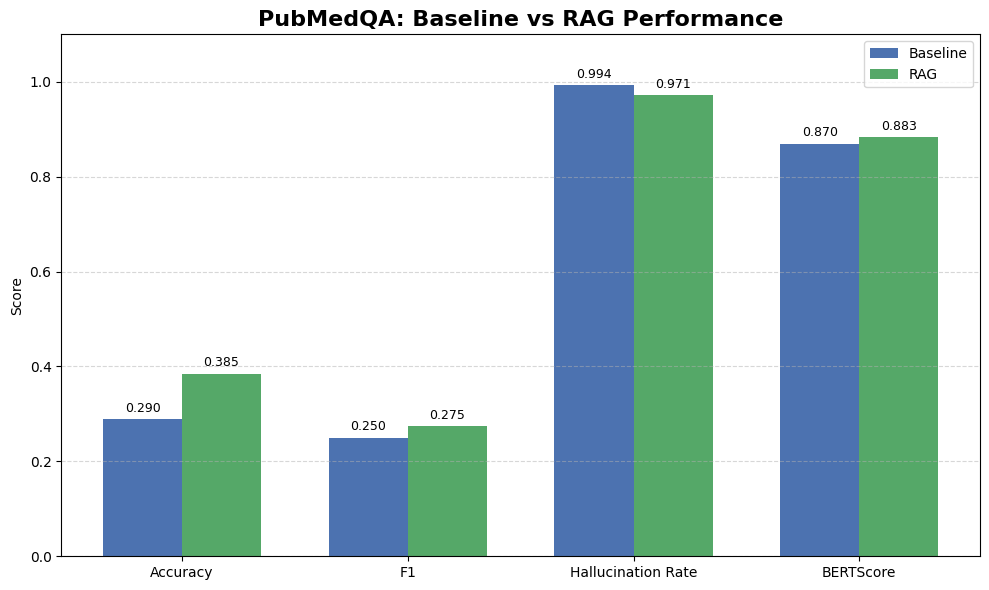

In [34]:
import matplotlib.pyplot as plt
import numpy as np

# =========================
# PubMedQA Metrics
# =========================
metrics = {
    "Baseline Accuracy": 0.29,
    "RAG Accuracy": 0.385,
    "Baseline F1": 0.2500917431192661,
    "RAG F1": 0.2752091254752852,
    "Baseline Hallucination Rate": 0.9936538461538461,
    "RAG Hallucination Rate": 0.971133283880087,
    "Baseline BERTScore": 0.8698808550834656,
    "RAG BERTScore": 0.8831617832183838
}

# =========================
# Prepare Data
# =========================
categories = ["Accuracy", "F1", "Hallucination Rate", "BERTScore"]

baseline_values = [
    metrics["Baseline Accuracy"],
    metrics["Baseline F1"],
    metrics["Baseline Hallucination Rate"],
    metrics["Baseline BERTScore"]
]

rag_values = [
    metrics["RAG Accuracy"],
    metrics["RAG F1"],
    metrics["RAG Hallucination Rate"],
    metrics["RAG BERTScore"]
]

# =========================
# Plot
# =========================
x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

baseline_bars = ax.bar(
    x - width / 2,
    baseline_values,
    width,
    label='Baseline',
    color='#4C72B0'
)

rag_bars = ax.bar(
    x + width / 2,
    rag_values,
    width,
    label='RAG',
    color='#55A868'
)

# =========================
# Labels & Styling
# =========================
ax.set_title("PubMedQA: Baseline vs RAG Performance", fontsize=16, fontweight='bold')
ax.set_ylabel("Score")
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_ylim(0, 1.1)
ax.legend()

# Add value labels on bars
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(
            f'{height:.3f}',
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 3),
            textcoords="offset points",
            ha='center',
            va='bottom',
            fontsize=9
        )

add_labels(baseline_bars)
add_labels(rag_bars)

# Grid for readability
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

/tmp/ipykernel_57/915440965.py:254: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


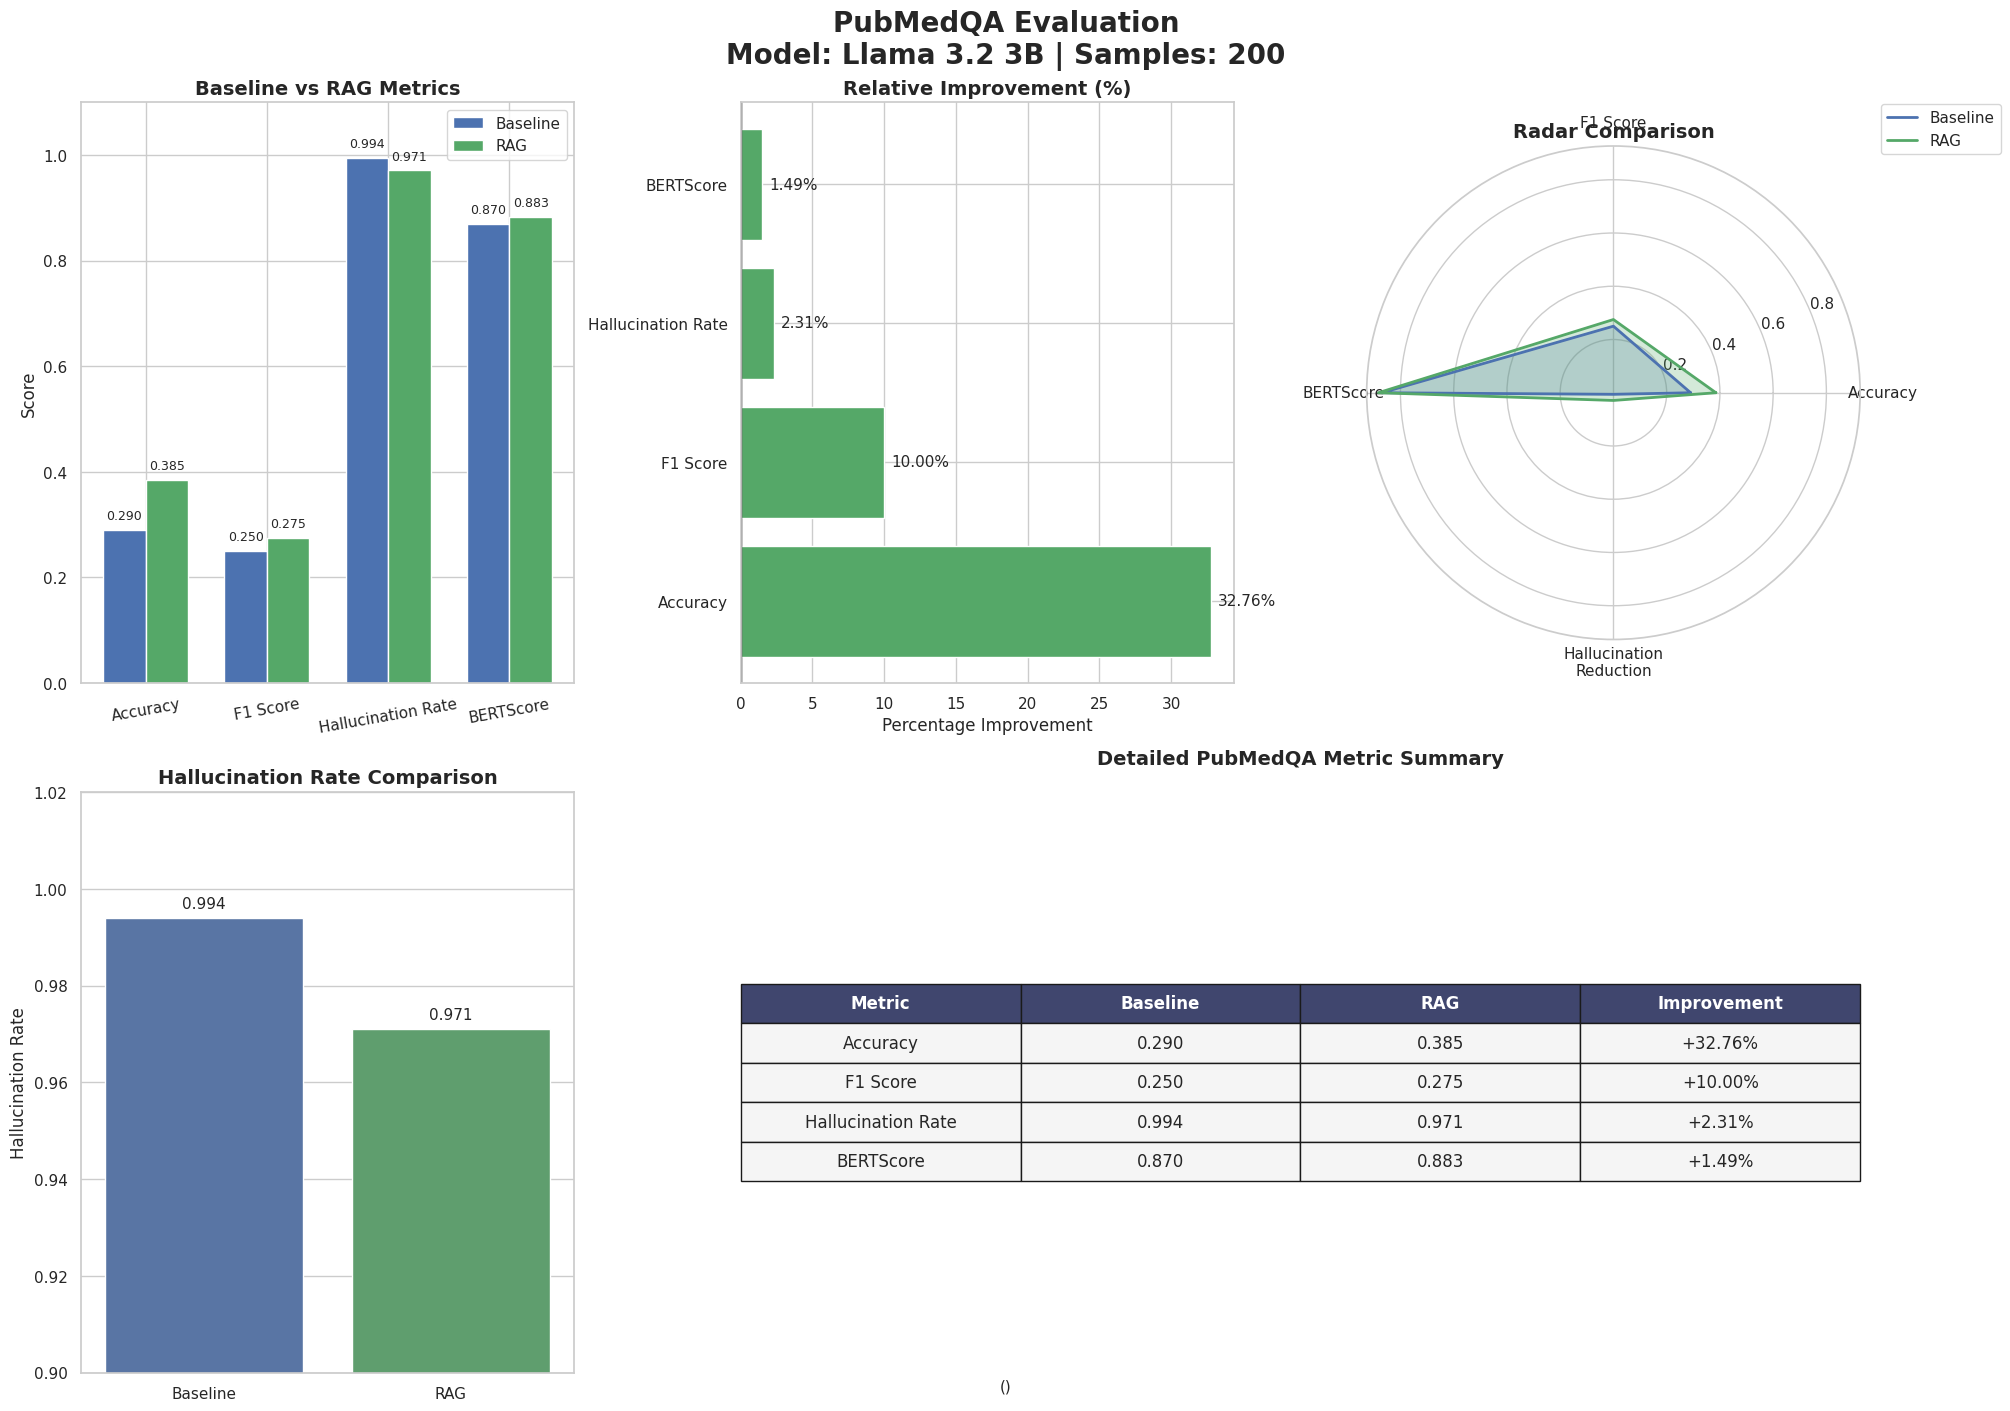

In [39]:
"""
Detailed PubMedQA Evaluation Visualization
Model: Llama 3.2 3B
Dataset Size: 200 Samples

Visualizations Included:
1. Performance comparison dashboard
2. Metric improvement analysis
3. Hallucination reduction plot
4. Radar chart comparison
5. Summary table

Requirements:
pip install matplotlib seaborn pandas numpy
"""

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from matplotlib.gridspec import GridSpec

# =========================================================
# CONFIG
# =========================================================

MODEL_NAME = "Llama 3.2 3B"
DATASET = "PubMedQA"
NUM_SAMPLES = 200

# =========================================================
# METRICS
# =========================================================

metrics = {
    "Accuracy": {
        "Baseline": 0.290,
        "RAG": 0.385
    },
    "F1 Score": {
        "Baseline": 0.250,
        "RAG": 0.275
    },
    "Hallucination Rate": {
        "Baseline": 0.994,
        "RAG": 0.971
    },
    "BERTScore": {
        "Baseline": 0.870,
        "RAG": 0.883
    }
}

# =========================================================
# DERIVED METRICS
# =========================================================

improvements = {}

for metric, values in metrics.items():
    baseline = values["Baseline"]
    rag = values["RAG"]

    if metric == "Hallucination Rate":
        # Lower is better
        improvement = ((baseline - rag) / baseline) * 100
    else:
        # Higher is better
        improvement = ((rag - baseline) / baseline) * 100

    improvements[metric] = improvement

# =========================================================
# STYLE
# =========================================================

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (18, 12)
plt.rcParams["font.size"] = 11

baseline_color = "#4C72B0"
rag_color = "#55A868"
improvement_color = "#C44E52"

# =========================================================
# FIGURE LAYOUT
# =========================================================

fig = plt.figure(constrained_layout=True, figsize=(20, 14))
gs = GridSpec(2, 3, figure=fig)

# =========================================================
# 1. GROUPED BAR CHART
# =========================================================

ax1 = fig.add_subplot(gs[0, 0])

categories = list(metrics.keys())
baseline_vals = [metrics[m]["Baseline"] for m in categories]
rag_vals = [metrics[m]["RAG"] for m in categories]

x = np.arange(len(categories))
width = 0.35

bars1 = ax1.bar(
    x - width/2,
    baseline_vals,
    width,
    label="Baseline",
    color=baseline_color
)

bars2 = ax1.bar(
    x + width/2,
    rag_vals,
    width,
    label="RAG",
    color=rag_color
)

ax1.set_title("Baseline vs RAG Metrics", fontsize=14, weight='bold')
ax1.set_ylabel("Score")
ax1.set_xticks(x)
ax1.set_xticklabels(categories, rotation=10)
ax1.set_ylim(0, 1.1)
ax1.legend()

# Add labels
for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax1.text(
            bar.get_x() + bar.get_width()/2,
            h + 0.02,
            f"{h:.3f}",
            ha='center',
            fontsize=9
        )

# =========================================================
# 2. IMPROVEMENT PERCENTAGE
# =========================================================

ax2 = fig.add_subplot(gs[0, 1])

imp_categories = list(improvements.keys())
imp_values = list(improvements.values())

colors = [
    rag_color if v >= 0 else improvement_color
    for v in imp_values
]

bars = ax2.barh(
    imp_categories,
    imp_values,
    color=colors
)

ax2.axvline(0, color='black', linewidth=1)
ax2.set_title("Relative Improvement (%)", fontsize=14, weight='bold')
ax2.set_xlabel("Percentage Improvement")

for bar in bars:
    w = bar.get_width()
    ax2.text(
        w + 0.5,
        bar.get_y() + bar.get_height()/2,
        f"{w:.2f}%",
        va='center'
    )

# =========================================================
# 3. RADAR CHART
# =========================================================

ax3 = fig.add_subplot(gs[0, 2], polar=True)

radar_categories = [
    "Accuracy",
    "F1 Score",
    "BERTScore",
    "Hallucination\nReduction"
]

baseline_radar = [
    metrics["Accuracy"]["Baseline"],
    metrics["F1 Score"]["Baseline"],
    metrics["BERTScore"]["Baseline"],
    1 - metrics["Hallucination Rate"]["Baseline"]
]

rag_radar = [
    metrics["Accuracy"]["RAG"],
    metrics["F1 Score"]["RAG"],
    metrics["BERTScore"]["RAG"],
    1 - metrics["Hallucination Rate"]["RAG"]
]

angles = np.linspace(0, 2*np.pi, len(radar_categories), endpoint=False).tolist()
angles += angles[:1]

baseline_radar += baseline_radar[:1]
rag_radar += rag_radar[:1]

ax3.plot(
    angles,
    baseline_radar,
    color=baseline_color,
    linewidth=2,
    label="Baseline"
)

ax3.fill(
    angles,
    baseline_radar,
    color=baseline_color,
    alpha=0.25
)

ax3.plot(
    angles,
    rag_radar,
    color=rag_color,
    linewidth=2,
    label="RAG"
)

ax3.fill(
    angles,
    rag_radar,
    color=rag_color,
    alpha=0.25
)

ax3.set_xticks(angles[:-1])
ax3.set_xticklabels(radar_categories)
ax3.set_title("Radar Comparison", fontsize=14, weight='bold')
ax3.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

# =========================================================
# 4. HALLUCINATION ANALYSIS
# =========================================================

ax4 = fig.add_subplot(gs[1, 0])

hallucination = [
    metrics["Hallucination Rate"]["Baseline"],
    metrics["Hallucination Rate"]["RAG"]
]

models = ["Baseline", "RAG"]

sns.barplot(
    x=models,
    y=hallucination,
    palette=[baseline_color, rag_color],
    ax=ax4
)

ax4.set_title("Hallucination Rate Comparison", fontsize=14, weight='bold')
ax4.set_ylabel("Hallucination Rate")
ax4.set_ylim(0.9, 1.02)

for i, val in enumerate(hallucination):
    ax4.text(i, val + 0.002, f"{val:.3f}", ha='center')

# =========================================================
# 5. METRIC TABLE
# =========================================================

ax5 = fig.add_subplot(gs[1, 1:])
ax5.axis('off')

table_data = []

for metric in metrics:
    table_data.append([
        metric,
        f"{metrics[metric]['Baseline']:.3f}",
        f"{metrics[metric]['RAG']:.3f}",
        f"{improvements[metric]:+.2f}%"
    ])

columns = [
    "Metric",
    "Baseline",
    "RAG",
    "Improvement"
]

table = ax5.table(
    cellText=table_data,
    colLabels=columns,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 2)

# Header styling
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor("#40466E")
    else:
        cell.set_facecolor("#F5F5F5")

ax5.set_title(
    "Detailed PubMedQA Metric Summary",
    fontsize=14,
    weight='bold',
    pad=20
)

# =========================================================
# GLOBAL TITLE
# =========================================================

fig.suptitle(
    f"{DATASET} Evaluation\n"
    f"Model: {MODEL_NAME} | Samples: {NUM_SAMPLES}",
    fontsize=20,
    weight='bold'
)

# =========================================================
# FOOTNOTE
# =========================================================

plt.figtext(
    0.5,
    0.01,
    (    
        
    ),
    ha='center',
    fontsize=11
)

plt.show()

In [33]:
medhallu_sample = medhallu_dataset.sample(
    n=200,
    random_state=42
).reset_index(drop=True)

#print("PubMedQA Sample Shape:", pubmedqa_sample.shape)
print("MedHallu Sample Shape:", medhallu_sample.shape)

medhallu_dataset_list = medhallu_sample.to_dict(orient="records")

MedHallu Sample Shape: (200, 6)


In [34]:
# PubMedQA Evaluation
#df_pubmedqa_results = evaluate_dataset(
#    pubmedqa_dataset_list,
#    k_retrieval=10,
#    rerank_k=20
#)

#metrics_pubmedqa = compute_metrics(df_pubmedqa_results)

#print(metrics_pubmedqa)


# MedHallu Evaluation
df_medhallu_results = evaluate_dataset(
    medhallu_dataset_list,
    k_retrieval=20,
    rerank_k=10
)

metrics_medhallu = compute_metrics(df_medhallu_results)

print("\nMedHallu Metrics")
print(metrics_medhallu)

  0%|          | 0/200 [00:00<?, ?it/s]


[RAG PROMPT LENGTH: 1379 chars]


  0%|          | 1/200 [00:39<2:12:11, 39.86s/it]


[RAG PROMPT LENGTH: 1345 chars]


  1%|          | 2/200 [00:58<1:29:52, 27.23s/it]

...

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



MedHallu Metrics
{'Baseline Accuracy': 0.345, 'RAG Accuracy': 0.385, 'Baseline F1': 0.2837662337662337, 'RAG F1': 0.2868627450980392, 'Baseline Hallucination Rate': np.float64(0.9947619047619048), 'RAG Hallucination Rate': np.float64(0.9575032936600948), 'Avg Retrieval Recall@K': nan, 'Baseline BERTScore': 0.8705828189849854, 'RAG BERTScore': 0.8817585706710815}


/tmp/ipykernel_57/3347799359.py:239: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


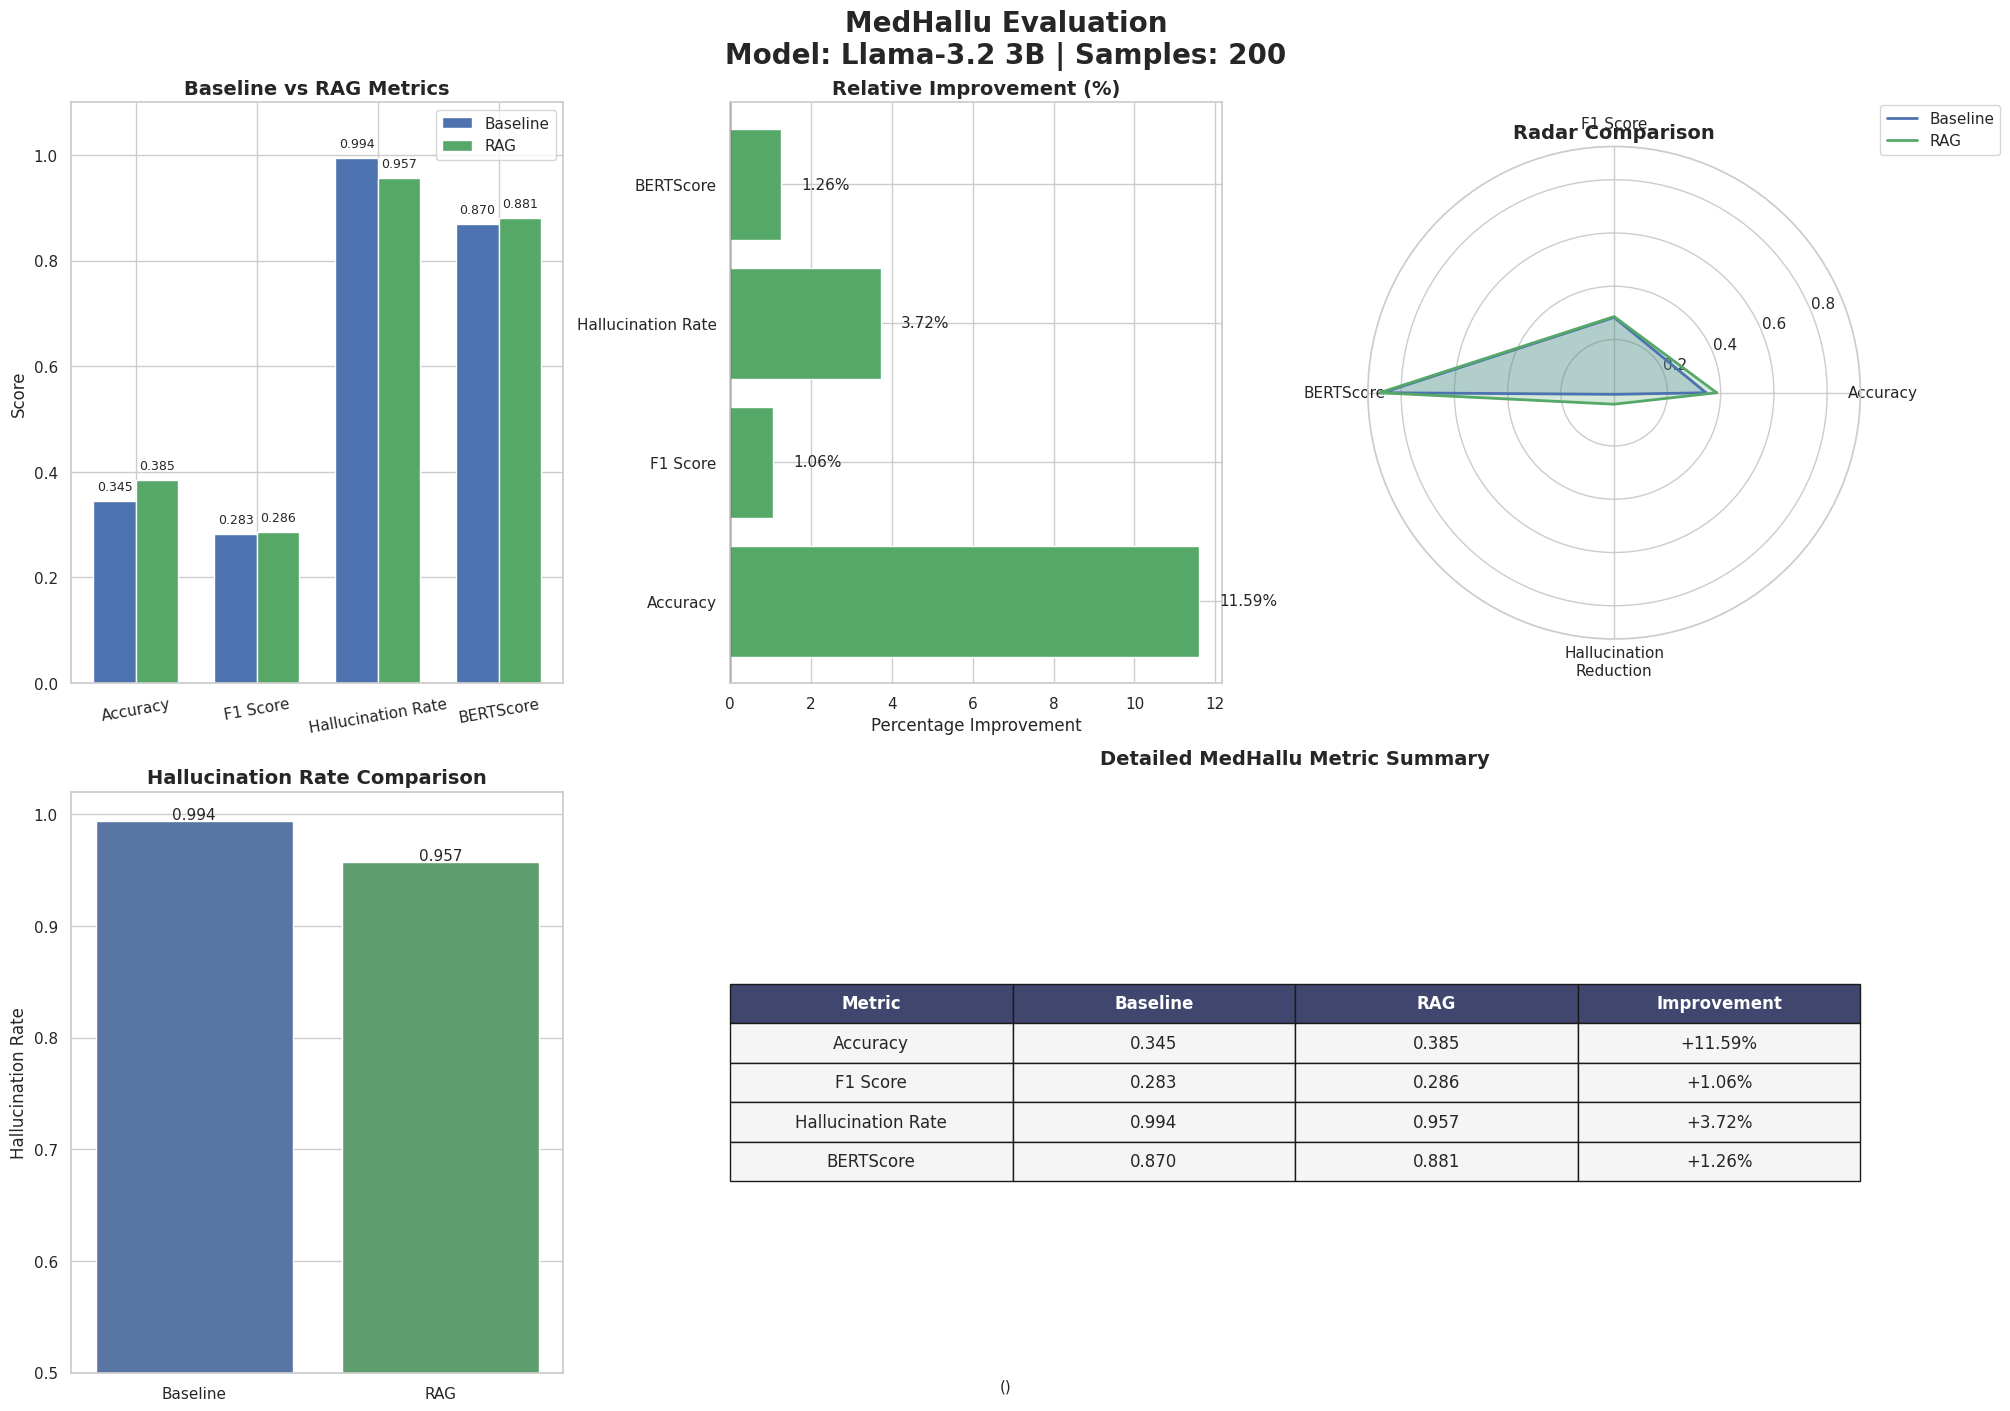

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from matplotlib.gridspec import GridSpec

# =========================================================
# CONFIG
# =========================================================

MODEL_NAME = "Llama-3.2 3B"
DATASET = "MedHallu"
NUM_SAMPLES = 200

# =========================================================
# METRICS
# =========================================================

metrics = {
    "Accuracy": {
        "Baseline": 0.345,
        "RAG": 0.385
    },
    "F1 Score": {
        "Baseline": 0.283,
        "RAG": 0.286
    },
    "Hallucination Rate": {
        "Baseline": 0.994,
        "RAG": 0.957
    },
    "BERTScore": {
        "Baseline": 0.870,
         "RAG": 0.881
    }
}

# =========================================================
# DERIVED METRICS
# =========================================================

improvements = {}

for metric, values in metrics.items():
    baseline = values["Baseline"]
    rag = values["RAG"]

    if metric == "Hallucination Rate":
        # Lower is better
        improvement = ((baseline - rag) / baseline) * 100
    else:
        # Higher is better
        improvement = ((rag - baseline) / baseline) * 100

    improvements[metric] = improvement

# =========================================================
# STYLE
# =========================================================

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (18, 12)
plt.rcParams["font.size"] = 11

baseline_color = "#4C72B0"
rag_color = "#55A868"
improvement_color = "#C44E52"

# =========================================================
# FIGURE LAYOUT
# =========================================================

fig = plt.figure(constrained_layout=True, figsize=(20, 14))
gs = GridSpec(2, 3, figure=fig)


# =========================================================
# 1. GROUPED BAR CHART
# =========================================================

ax1 = fig.add_subplot(gs[0, 0])

categories = list(metrics.keys())
baseline_vals = [metrics[m]["Baseline"] for m in categories]
rag_vals = [metrics[m]["RAG"] for m in categories]

x = np.arange(len(categories))
width = 0.35

bars1 = ax1.bar(
    x - width/2,
    baseline_vals,
    width,
    label="Baseline",
    color=baseline_color
)

bars2 = ax1.bar(
    x + width/2,
    rag_vals,
    width,
    label="RAG",
    color=rag_color
)

ax1.set_title("Baseline vs RAG Metrics", fontsize=14, weight='bold')
ax1.set_ylabel("Score")
ax1.set_xticks(x)
ax1.set_xticklabels(categories, rotation=10)
ax1.set_ylim(0, 1.1)
ax1.legend()

# Add labels
for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax1.text(
            bar.get_x() + bar.get_width()/2,
            h + 0.02,
            f"{h:.3f}",
            ha='center',
            fontsize=9
        )

# =========================================================
# 2. IMPROVEMENT PERCENTAGE
# =========================================================

ax2 = fig.add_subplot(gs[0, 1])

imp_categories = list(improvements.keys())
imp_values = list(improvements.values())

colors = [
     rag_color if v >= 0 else improvement_color
    for v in imp_values
]

bars = ax2.barh(
    imp_categories,
    imp_values,
    color=colors
)

ax2.axvline(0, color='black', linewidth=1)
ax2.set_title("Relative Improvement (%)", fontsize=14, weight='bold')
ax2.set_xlabel("Percentage Improvement")

for bar in bars:
    w = bar.get_width()
    ax2.text(
        w + 0.5,
        bar.get_y() + bar.get_height()/2,
        f"{w:.2f}%",
        va='center'
    )

# =========================================================
# 3. RADAR CHART
# =========================================================

ax3 = fig.add_subplot(gs[0, 2], polar=True)

radar_categories = [
    "Accuracy",
    "F1 Score",
    "BERTScore",
    "Hallucination\nReduction"
]

baseline_radar = [
    metrics["Accuracy"]["Baseline"],
    metrics["F1 Score"]["Baseline"],
    metrics["BERTScore"]["Baseline"],
    1 - metrics["Hallucination Rate"]["Baseline"]
]

rag_radar = [
    metrics["Accuracy"]["RAG"],
    metrics["F1 Score"]["RAG"],
    metrics["BERTScore"]["RAG"],
    1 - metrics["Hallucination Rate"]["RAG"]
]

angles = np.linspace(0, 2*np.pi, len(radar_categories), endpoint=False).tolist()
angles += angles[:1]

baseline_radar += baseline_radar[:1]
rag_radar += rag_radar[:1]

ax3.plot(
    angles,
    baseline_radar,
     color=baseline_color,
    linewidth=2,
    label="Baseline"
)

ax3.fill(
    angles,
     baseline_radar,
    color=baseline_color,
    alpha=0.25
)

ax3.plot(
    angles,
    rag_radar,
    color=rag_color,
    linewidth=2,
    label="RAG"
)

ax3.fill(
    angles,
    rag_radar,
    color=rag_color,
    alpha=0.25
)

ax3.set_xticks(angles[:-1])
ax3.set_xticklabels(radar_categories)
ax3.set_title("Radar Comparison", fontsize=14, weight='bold')
ax3.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

# =========================================================
# 4. HALLUCINATION ANALYSIS
# =========================================================

ax4 = fig.add_subplot(gs[1, 0])

hallucination = [
     metrics["Hallucination Rate"]["Baseline"],
     metrics["Hallucination Rate"]["RAG"]
]

models = ["Baseline", "RAG"]

sns.barplot(
    x=models,
    y=hallucination,
    palette=[baseline_color, rag_color],
    ax=ax4
)

ax4.set_title("Hallucination Rate Comparison", fontsize=14, weight='bold')
ax4.set_ylabel("Hallucination Rate")
ax4.set_ylim(0.5, 1.02)

for i, val in enumerate(hallucination):
    ax4.text(i, val + 0.002, f"{val:.3f}", ha='center')

# =========================================================
# 5. METRIC TABLE
# =========================================================

ax5 = fig.add_subplot(gs[1, 1:])
ax5.axis('off')

table_data = []

for metric in metrics:
    table_data.append([
        metric,
        f"{metrics[metric]['Baseline']:.3f}",
        f"{metrics[metric]['RAG']:.3f}",
         f"{improvements[metric]:+.2f}%"
    ])

columns = [
    "Metric",
     "Baseline",
    "RAG",
    "Improvement"
]

table = ax5.table(
    cellText=table_data,
    colLabels=columns,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 2)

# Header styling
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor("#40466E")
    else:
        cell.set_facecolor("#F5F5F5")

ax5.set_title(
    "Detailed MedHallu Metric Summary",
    fontsize=14,
    weight='bold',
    pad=20
)

# =========================================================
# GLOBAL TITLE
# =========================================================

fig.suptitle(
    f"{DATASET} Evaluation\n"
    f"Model: {MODEL_NAME} | Samples: {NUM_SAMPLES}",
    fontsize=20,
     weight='bold'
)

# =========================================================
# FOOTNOTE
# =========================================================

plt.figtext(
    0.5,
    0.01,
    (    
        
    ),
    ha='center',
    fontsize=11
)

plt.show()

In [33]:
df_pubmedqa_results.to_csv(
    "pubmedqa_50_llama_results.csv",
    index=False
)




In [36]:

df_medhallu_results.to_csv(
    "medhallu_200_llama_results.csv",
    index=False
)

In [ ]:
# Evaluate PubMedQA
#df_pubmedqa_results = evaluate_dataset(pubmedqa_dataset_list, k_retrieval=10, rerank_k=20)
#metrics_pubmedqa = compute_metrics(df_pubmedqa_results)
#print("PubMedQA Metrics:")
#print(metrics_pubmedqa)

batch_size = 50  # adjust depending on your GPU memory
all_medhallu_results = []

for i in range(0, len(medhallu_dataset_list), batch_size):
    batch = medhallu_dataset_list[i:i+batch_size]
    df_batch = evaluate_dataset(batch, k_retrieval=10, rerank_k=20)
    all_medhallu_results.append(df_batch)


df_medhallu_results = pd.concat(all_medhallu_results, ignore_index=True)
metrics_pubmedqa = compute_metrics(df_medhallu_results)
print("PubMedQA Metrics:")
print(metrics_pubmedqa)

# Evaluate MedHallu
#df_medhallu_results = evaluate_dataset(medhallu_dataset_list, k_retrieval=10, rerank_k=20)
#metrics_medhallu = compute_metrics(df_medhallu_results)
#print("MedHallu Metrics:")
#print(metrics_medhallu)

In [ ]:
df_pubmedqa_results.to_csv("pubmedqa_detailed_results.csv", index=False)
df_medhallu_results.to_csv("medhallu_detailed_results.csv", index=False)

In [21]:
import pandas as pd
import numpy as np
from scipy import stats
from rouge_score import rouge_scorer
from bert_score import score as bert_score
import json
import time
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# ===== EVALUATION METRICS CLASS =====
class MedicalQAEvaluator:
    """Comprehensive evaluation metrics for medical QA systems"""
    
    def __init__(self):
        self.rouge_scorer = rouge_scorer.RougeScorer(['rouge1', 'rougeL'], use_stemmer=True)
    
    def exact_match(self, predicted, reference):
        """Binary exact match - 1 if exact, 0 otherwise"""
        return int(predicted.lower().strip() == reference.lower().strip())
    
    def f1_score(self, predicted, reference):
        """Token-level F1 score"""
        pred_tokens = set(predicted.lower().split())
        ref_tokens = set(reference.lower().split())
        
        if len(pred_tokens) == 0 and len(ref_tokens) == 0:
            return 1.0
        if len(pred_tokens) == 0 or len(ref_tokens) == 0:
            return 0.0
        
        common = pred_tokens & ref_tokens
        precision = len(common) / len(pred_tokens) if pred_tokens else 0
        recall = len(common) / len(ref_tokens) if ref_tokens else 0
        
        if precision + recall == 0:
            return 0.0
        
        f1 = 2 * (precision * recall) / (precision + recall)
        return f1
    
    def rouge_l(self, predicted, reference):
        """ROUGE-L score (longest common subsequence)"""
        scores = self.rouge_scorer.score(reference, predicted)
        return scores['rougeL'].fmeasure
    
    def bleu_score(self, predicted, reference, n=4):
        """Simplified BLEU score calculation"""
        from collections import Counter
        
        pred_tokens = predicted.lower().split()
        ref_tokens = reference.lower().split()
        
        if not pred_tokens or not ref_tokens:
            return 0.0
        
        # Count n-gram matches
        matches = 0
        for i in range(len(pred_tokens) - n + 1):
            ngram = tuple(pred_tokens[i:i+n])
            if ngram in [tuple(ref_tokens[j:j+n]) for j in range(len(ref_tokens) - n + 1)]:
                matches += 1
        
        ngram_count = max(1, len(pred_tokens) - n + 1)
        return matches / ngram_count if ngram_count > 0 else 0.0
    
    def evaluate_single(self, predicted, reference):
        """Evaluate a single prediction"""
        return {
            'exact_match': self.exact_match(predicted, reference),
            'f1': self.f1_score(predicted, reference),
            'rouge_l': self.rouge_l(predicted, reference),
            'bleu': self.bleu_score(predicted, reference),
        }
    
    def evaluate_batch(self, predictions, references):
        """Evaluate batch of predictions"""
        results = []
        for pred, ref in tqdm(zip(predictions, references), total=len(predictions), desc="Evaluating"):
            results.append(self.evaluate_single(pred, ref))
        
        return pd.DataFrame(results)

# ===== STRATIFIED SAMPLING =====
def create_stratified_sample(questions_df, sample_size=200, random_state=42):
    """
    Create stratified random sample from questions DataFrame
    
    Args:
        questions_df: DataFrame with columns ['question', 'domain', 'complexity', 'reference_answer']
        sample_size: Number of questions to sample (200-300 recommended)
        random_state: For reproducibility
    
    Returns:
        DataFrame: Stratified sample
    """
    if 'domain' not in questions_df.columns or 'complexity' not in questions_df.columns:
        print("[WARNING] No domain/complexity columns. Using random sampling instead.")
        return questions_df.sample(n=min(sample_size, len(questions_df)), random_state=random_state).reset_index(drop=True)
    
    # Stratified sampling by domain and complexity
    stratified_sample = questions_df.groupby(['domain', 'complexity'], group_keys=False).apply(
        lambda x: x.sample(frac=sample_size/len(questions_df), random_state=random_state)
    ).reset_index(drop=True)
    
    # If sample is too large, trim it
    if len(stratified_sample) > sample_size:
        stratified_sample = stratified_sample.sample(n=sample_size, random_state=random_state).reset_index(drop=True)
    
    return stratified_sample

# ===== STATISTICAL TESTING =====
class StatisticalAnalysis:
    """Statistical comparison between baseline and RAG systems"""
    
    @staticmethod
    def paired_ttest(baseline_scores, rag_scores, metric_name="Metric"):
        """Perform paired t-test"""
        t_stat, p_value = stats.ttest_rel(baseline_scores, rag_scores)
        
        # Calculate effect size (Cohen's d)
        diff = np.array(baseline_scores) - np.array(rag_scores)
        cohen_d = np.mean(diff) / np.std(diff) if np.std(diff) > 0 else 0
        
        # Calculate 95% confidence interval
        mean_diff = np.mean(diff)
        std_err = stats.sem(diff)
        ci = stats.t.interval(0.95, len(diff)-1, loc=mean_diff, scale=std_err)
        
        return {
            'metric': metric_name,
            't_statistic': t_stat,
            'p_value': p_value,
            'cohens_d': cohen_d,
            'mean_difference': mean_diff,
            'ci_lower': ci[0],
            'ci_upper': ci[1],
            'significant': p_value < 0.05
        }
    
    @staticmethod
    def compare_systems(baseline_df, rag_df):
        """Compare baseline vs RAG across all metrics"""
        results = []
        metrics = ['exact_match', 'f1', 'rouge_l', 'bleu']
        
        for metric in metrics:
            test_result = StatisticalAnalysis.paired_ttest(
                baseline_df[metric].values,
                rag_df[metric].values,
                metric_name=metric
            )
            results.append(test_result)
        
        return pd.DataFrame(results)

# ===== MAIN EVALUATION PIPELINE =====
class EvaluationPipeline:
    """Complete evaluation pipeline"""
    
    def __init__(self, baseline_results_file, rag_results_file, reference_answers_file):
        """
        Initialize evaluation pipeline
        
        Args:
            baseline_results_file: JSON or CSV file with baseline predictions
            rag_results_file: JSON or CSV file with RAG predictions
            reference_answers_file: JSON or CSV file with reference answers
        """
        self.baseline_results = self._load_file(baseline_results_file)
        self.rag_results = self._load_file(rag_results_file)
        self.reference_answers = self._load_file(reference_answers_file)
        self.evaluator = MedicalQAEvaluator()
    
    @staticmethod
    def _load_file(filepath):
        """Load JSON or CSV file"""
        if filepath.endswith('.json'):
            with open(filepath, 'r') as f:
                return json.load(f)
        elif filepath.endswith('.csv'):
            return pd.read_csv(filepath)
        else:
            raise ValueError("File must be .json or .csv")
    
    def run_evaluation(self):
        """Run full evaluation"""
        print("=" * 80)
        print("MEDICAL QA EVALUATION PIPELINE")
        print("=" * 80)
        
        # Convert to lists if needed
        if isinstance(self.baseline_results, pd.DataFrame):
            baseline_preds = self.baseline_results['prediction'].tolist()
        else:
            baseline_preds = [r['prediction'] for r in self.baseline_results]
        
        if isinstance(self.rag_results, pd.DataFrame):
            rag_preds = self.rag_results['prediction'].tolist()
        else:
            rag_preds = [r['prediction'] for r in self.rag_results]
        
        if isinstance(self.reference_answers, pd.DataFrame):
            ref_answers = self.reference_answers['answer'].tolist()
        else:
            ref_answers = [r['answer'] for r in self.reference_answers]
        
        # Evaluate both systems
        print("\n[1/4] Evaluating Baseline LLM...")
        baseline_metrics = self.evaluator.evaluate_batch(baseline_preds, ref_answers)
        
        print("\n[2/4] Evaluating RAG LLM...")
        rag_metrics = self.evaluator.evaluate_batch(rag_preds, ref_answers)
        
        # Statistical comparison
        print("\n[3/4] Running Statistical Tests...")
        stat_results = StatisticalAnalysis.compare_systems(baseline_metrics, rag_metrics)
        
        # Generate report
        print("\n[4/4] Generating Report...")
        report = self._generate_report(baseline_metrics, rag_metrics, stat_results)
        
        return {
            'baseline_metrics': baseline_metrics,
            'rag_metrics': rag_metrics,
            'statistical_results': stat_results,
            'report': report
        }
    
    def _generate_report(self, baseline_metrics, rag_metrics, stat_results):
        """Generate detailed evaluation report"""
        report = {}
        
        # Overall metrics comparison
        report['overall_comparison'] = {
            'baseline': {
                'exact_match': baseline_metrics['exact_match'].mean(),
                'f1': baseline_metrics['f1'].mean(),
                'rouge_l': baseline_metrics['rouge_l'].mean(),
                'bleu': baseline_metrics['bleu'].mean(),
            },
            'rag': {
                'exact_match': rag_metrics['exact_match'].mean(),
                'f1': rag_metrics['f1'].mean(),
                'rouge_l': rag_metrics['rouge_l'].mean(),
                'bleu': rag_metrics['bleu'].mean(),
            }
        }
        
        # Calculate improvements
        report['improvements'] = {}
        for metric in ['exact_match', 'f1', 'rouge_l', 'bleu']:
            baseline_mean = baseline_metrics[metric].mean()
            rag_mean = rag_metrics[metric].mean()
            improvement = ((rag_mean - baseline_mean) / baseline_mean * 100) if baseline_mean > 0 else 0
            report['improvements'][metric] = improvement
        
        # Statistical significance
        report['statistical_tests'] = stat_results.to_dict('records')
        
        return report

# ===== VISUALIZATION =====
class ResultsVisualizer:
    """Visualize evaluation results"""
    
    @staticmethod
    def plot_metrics_comparison(baseline_df, rag_df, output_file='metrics_comparison.png'):
        """Plot metrics comparison"""
        metrics = ['exact_match', 'f1', 'rouge_l', 'bleu']
        
        baseline_means = [baseline_df[m].mean() for m in metrics]
        rag_means = [rag_df[m].mean() for m in metrics]
        
        fig, ax = plt.subplots(figsize=(10, 6))
        
        x = np.arange(len(metrics))
        width = 0.35
        
        ax.bar(x - width/2, baseline_means, width, label='Baseline LLM', color='skyblue')
        ax.bar(x + width/2, rag_means, width, label='RAG LLM', color='lightcoral')
        
        ax.set_xlabel('Metrics')
        ax.set_ylabel('Score')
        ax.set_title('Baseline vs RAG LLM - Metrics Comparison')
        ax.set_xticks(x)
        ax.set_xticklabels(metrics)
        ax.legend()
        ax.grid(axis='y', alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(output_file, dpi=300)
        print(f"\n[✓] Saved: {output_file}")
        plt.close()
    
    @staticmethod
    def plot_distribution(baseline_df, rag_df, metric='f1', output_file='metric_distribution.png'):
        """Plot distribution of a metric"""
        fig, ax = plt.subplots(figsize=(10, 6))
        
        ax.hist(baseline_df[metric], bins=20, alpha=0.6, label='Baseline LLM', color='skyblue')
        ax.hist(rag_df[metric], bins=20, alpha=0.6, label='RAG LLM', color='lightcoral')
        
        ax.set_xlabel(metric.upper())
        ax.set_ylabel('Frequency')
        ax.set_title(f'Distribution of {metric.upper()}')
        ax.legend()
        ax.grid(alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(output_file, dpi=300)
        print(f"\n[✓] Saved: {output_file}")
        plt.close()
    
    @staticmethod
    def print_summary_table(report):
        """Print summary table"""
        print("\n" + "=" * 80)
        print("EVALUATION SUMMARY")
        print("=" * 80)
        
        print("\nOVERALL METRICS:")
        print("-" * 80)
        print(f"{'Metric':<20} {'Baseline':<20} {'RAG':<20} {'Improvement':<20}")
        print("-" * 80)
        
        for metric in ['exact_match', 'f1', 'rouge_l', 'bleu']:
            baseline = report['overall_comparison']['baseline'][metric]
            rag = report['overall_comparison']['rag'][metric]
            improvement = report['improvements'][metric]
            
            print(f"{metric:<20} {baseline:<20.4f} {rag:<20.4f} {improvement:<20.2f}%")
        
        print("\nSTATISTICAL SIGNIFICANCE:")
        print("-" * 80)
        print(f"{'Metric':<20} {'t-statistic':<15} {'p-value':<15} {'Significant':<15}")
        print("-" * 80)
        
        for test in report['statistical_tests']:
            sig = "✓ YES" if test['significant'] else "✗ NO"
            print(f"{test['metric']:<20} {test['t_statistic']:<15.4f} {test['p_value']:<15.4f} {sig:<15}")

# ===== USAGE EXAMPLE =====
if __name__ == "__main__":
    
    # Example: Load your results
    # pipeline = EvaluationPipeline(
    #     baseline_results_file='baseline_results.json',
    #     rag_results_file='rag_results.json',
    #     reference_answers_file='reference_answers.json'
    # )
    
    # Run evaluation
    # results = pipeline.run_evaluation()
    
    # Print summary
    # ResultsVisualizer.print_summary_table(results['report'])
    
    # Generate plots
    # ResultsVisualizer.plot_metrics_comparison(results['baseline_metrics'], results['rag_metrics'])
    # ResultsVisualizer.plot_distribution(results['baseline_metrics'], results['rag_metrics'], metric='f1')
    
    # Save detailed report
    # with open('evaluation_report.json', 'w') as f:
    #     json.dump(results['report'], f, indent=4)
    
    print("Evaluation code ready to use!")
    print("\nRequired input files:")
    print("  1. baseline_results.json (or .csv) - Baseline LLM predictions")
    print("  2. rag_results.json (or .csv) - RAG LLM predictions")
    print("  3. reference_answers.json (or .csv) - Ground truth answers")
    print("\nEach file should have a 'prediction' or 'answer' column.")


Evaluation code ready to use!

Required input files:
  1. baseline_results.json (or .csv) - Baseline LLM predictions
  2. rag_results.json (or .csv) - RAG LLM predictions
  3. reference_answers.json (or .csv) - Ground truth answers

Each file should have a 'prediction' or 'answer' column.


In [18]:
!pip install bert_score 

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 2.0 MB/s eta 0:00:00


In [35]:
import random
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from difflib import SequenceMatcher

# ===== SET RANDOM SEED =====
random.seed(42)
np.random.seed(42)

# ===== RANDOM SAMPLING (50 + 50) =====
med_sample_size = 50
pubmed_sample_size = 50

med_random_indices = random.sample(range(len(med_test)), med_sample_size)
pubmed_random_indices = random.sample(range(len(pubmed_test)), pubmed_sample_size)

med_test_sample = med_test.iloc[med_random_indices].reset_index(drop=True)
pubmed_test_sample = pubmed_test.iloc[pubmed_random_indices].reset_index(drop=True)

print(f"Med test sample size: {len(med_test_sample)}")
print(f"Pubmed test sample size: {len(pubmed_test_sample)}")
print(f"Total sample size: {len(med_test_sample) + len(pubmed_test_sample)}\n")

# ===== PARSE SAMPLED DATA =====
def parse_test_data(test_df, source='med'):
    """
    Parse test data - both med and pubmed have same structure: question, answer, context
    Returns: list of dicts with normalized structure
    """
    parsed = []
    
    for idx, row in test_df.iterrows():
        parsed.append({
            'question': row['question'],
            'ground_truth_answer': row['answer'],
            'context': row['context'],
            'source': source,
            'idx': idx
        })
    
    return parsed

# Parse both sampled datasets
med_parsed = parse_test_data(med_test_sample, source='med')
pubmed_parsed = parse_test_data(pubmed_test_sample, source='pubmed')
all_parsed = med_parsed + pubmed_parsed

print(f"Parsed {len(med_parsed)} med samples + {len(pubmed_parsed)} pubmed samples")
print(f"Total samples: {len(all_parsed)}\n")

# ===== EVALUATION FUNCTIONS =====

def normalize_answer(answer):
    """
    Normalize answer for comparison (handle Yes/No/Maybe, remove extra spaces, etc.)
    """
    if isinstance(answer, str):
        answer = answer.strip().lower()
        # Normalize common variations
        if answer in ['yes', 'y', 'true', '1']:
            return 'yes'
        elif answer in ['no', 'n', 'false', '0']:
            return 'no'
        elif answer in ['maybe', 'uncertain', 'unclear', '?']:
            return 'maybe'
    return answer

def exact_match(predicted, ground_truth):
    """
    Check if prediction exactly matches ground truth (after normalization)
    Works best for Yes/No/Maybe answers
    """
    if predicted is None or ground_truth is None:
        return False
    
    pred_norm = normalize_answer(str(predicted))
    gt_norm = normalize_answer(str(ground_truth))
    return pred_norm == gt_norm

def fuzzy_match(predicted, ground_truth, threshold=0.8):
    """
    Check if prediction is similar to ground truth (similarity score)
    Useful for longer, free-form answers
    """
    if predicted is None or ground_truth is None:
        return False
    
    pred = str(predicted).lower().strip()
    gt = str(ground_truth).lower().strip()
    similarity = SequenceMatcher(None, pred, gt).ratio()
    return similarity >= threshold

def evaluate_answers(test_samples, generated_answers, match_type='exact'):
    """
    Evaluate generated answers against ground truth
    
    Args:
        test_samples: list of parsed test data dicts
        generated_answers: list of generated model outputs
        match_type: 'exact' or 'fuzzy'
    
    Returns:
        dict with evaluation metrics and predictions
    """
    
    if match_type == 'exact':
        match_fn = exact_match
    else:
        match_fn = fuzzy_match
    
    predictions = []
    
    for i, sample in enumerate(test_samples):
        gt = sample['ground_truth_answer']
        generated = generated_answers[i] if i < len(generated_answers) else None
        
        # Convert to binary label (match=1, no match=0)
        is_match = 1 if match_fn(generated, gt) else 0
        predictions.append(is_match)
    
    # All ground truths are 1 (correct answer exists)
    ground_truths = [1] * len(test_samples)
    
    # Calculate metrics
    metrics = calculate_metrics(ground_truths, predictions)
    
    return metrics, predictions

def calculate_metrics(ground_truth, predictions, label='Model'):
    """
    Calculate accuracy, precision, recall, and F1 score
    """
    accuracy = accuracy_score(ground_truth, predictions)
    precision = precision_score(ground_truth, predictions, zero_division=0)
    recall = recall_score(ground_truth, predictions, zero_division=0)
    f1 = f1_score(ground_truth, predictions, zero_division=0)
    
    cm = confusion_matrix(ground_truth, predictions)
    if cm.size == 4:
        tn, fp, fn, tp = cm.ravel()
    else:
        # Handle edge cases
        tp = cm[0, 0] if cm.shape[0] > 0 and cm.shape[1] > 0 else 0
        tn = fp = fn = 0
    
    # Count correct and incorrect predictions
    correct_predictions = sum(predictions)
    incorrect_predictions = len(predictions) - correct_predictions
    
    metrics = {
        'label': label,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'true_positives': tp,
        'true_negatives': tn,
        'false_positives': fp,
        'false_negatives': fn,
        'correct_predictions': correct_predictions,
        'incorrect_predictions': incorrect_predictions,
        'total_samples': len(predictions)
    }
    
    return metrics

def print_metrics(metrics):
    """
    Pretty print metrics for a single model
    """
    print(f"\n{metrics['label']} RESULTS:")
    print(f"  Accuracy:  {metrics['accuracy']:.4f}")
    print(f"  Precision: {metrics['precision']:.4f}")
    print(f"  Recall:    {metrics['recall']:.4f}")
    print(f"  F1 Score:  {metrics['f1']:.4f}")
    print(f"\n  Predictions:")
    print(f"    Correct:   {metrics['correct_predictions']}")
    print(f"    Incorrect: {metrics['incorrect_predictions']}")
    print(f"    Total:     {metrics['total_samples']}")

def print_comparison(baseline_metrics, rag_metrics):
    """
    Compare baseline vs RAG performance
    """
    print(f"\n{'BASELINE vs RAG COMPARISON':-^60}")
    metrics_to_compare = ['accuracy', 'precision', 'recall', 'f1']
    
    for metric in metrics_to_compare:
        baseline_val = baseline_metrics[metric]
        rag_val = rag_metrics[metric]
        improvement = rag_val - baseline_val
        improvement_pct = (improvement / baseline_val * 100) if baseline_val != 0 else 0
        
        symbol = "↑" if improvement > 0 else "↓" if improvement < 0 else "="
        print(f"{metric.upper():12} | Baseline: {baseline_val:.4f} | RAG: {rag_val:.4f} | "
              f"Change: {symbol} {improvement:+.4f} ({improvement_pct:+.1f}%)")

# ===== FULL EVALUATION PIPELINE =====

def run_full_evaluation(baseline_results, rag_results, match_type='exact'):
    """
    Run complete evaluation on both med and pubmed splits
    
    Args:
        baseline_results: list of baseline model answers
        rag_results: list of RAG model answers
        match_type: 'exact' or 'fuzzy'
    
    Returns:
        dict with results for all splits
    """
    
    # Split results by source
    med_baseline = baseline_results[:len(med_parsed)]
    med_rag = rag_results[:len(med_parsed)]
    pubmed_baseline = baseline_results[len(med_parsed):]
    pubmed_rag = rag_results[len(med_parsed):]
    
    # Evaluate each split
    print("\n" + "="*80)
    print("MEDICAL TEST SET EVALUATION (n=50)")
    print("="*80)
    med_baseline_metrics, _ = evaluate_answers(med_parsed, med_baseline, match_type=match_type)
    med_rag_metrics, _ = evaluate_answers(med_parsed, med_rag, match_type=match_type)
    print_metrics(med_baseline_metrics)
    print_metrics(med_rag_metrics)
    print_comparison(med_baseline_metrics, med_rag_metrics)
    
    print("\n" + "="*80)
    print("PUBMED TEST SET EVALUATION (n=50)")
    print("="*80)
    pubmed_baseline_metrics, _ = evaluate_answers(pubmed_parsed, pubmed_baseline, match_type=match_type)
    pubmed_rag_metrics, _ = evaluate_answers(pubmed_parsed, pubmed_rag, match_type=match_type)
    print_metrics(pubmed_baseline_metrics)
    print_metrics(pubmed_rag_metrics)
    print_comparison(pubmed_baseline_metrics, pubmed_rag_metrics)
    
    print("\n" + "="*80)
    print("COMBINED EVALUATION (MED + PUBMED, n=100)")
    print("="*80)
    combined_baseline_metrics, _ = evaluate_answers(all_parsed, baseline_results, match_type=match_type)
    combined_rag_metrics, _ = evaluate_answers(all_parsed, rag_results, match_type=match_type)
    print_metrics(combined_baseline_metrics)
    print_metrics(combined_rag_metrics)
    print_comparison(combined_baseline_metrics, combined_rag_metrics)
    
    return {
        'med': {'baseline': med_baseline_metrics, 'rag': med_rag_metrics},
        'pubmed': {'baseline': pubmed_baseline_metrics, 'rag': pubmed_rag_metrics},
        'combined': {'baseline': combined_baseline_metrics, 'rag': combined_rag_metrics}
    }

# ===== GENERATE BASELINE AND RAG ANSWERS =====

print("Generating baseline and RAG answers for sampled data...")
print("="*80)

baseline_results = []
rag_results = []

for i, sample in enumerate(all_parsed):
    question = sample['question']
    
    # Generate baseline answer
    print(f"\n[{i+1}/{len(all_parsed)}] Processing: {question[:60]}...")
    baseline_ans = baseline_answer(question)
    baseline_results.append(baseline_ans)
    print(f"  Baseline: {baseline_ans[:100]}...")
    
    # Generate RAG answer (retrieve docs first)
    retrieved_docs = retrieve(question, k=100, rerank_k=20)
    rag_ans = rag_answer(question, retrieved_docs, k=10)
    rag_results.append(rag_ans)
    print(f"  RAG:      {rag_ans[:100]}...")

print(f"\n✓ Completed! Generated {len(baseline_results)} baseline and {len(rag_results)} RAG answers\n")

# ===== RUN EVALUATION =====

all_results = run_full_evaluation(baseline_results, rag_results, match_type='exact')

# ===== SAVE RESULTS TO JSON =====

import json

results_summary = {
    'metadata': {
        'total_samples': len(all_parsed),
        'med_samples': len(med_parsed),
        'pubmed_samples': len(pubmed_parsed),
        'match_type': 'exact',
        'random_seed': 42
    },
    'med': {
        'baseline': {k: float(v) if isinstance(v, (int, np.floating)) else v 
                     for k, v in all_results['med']['baseline'].items()},
        'rag': {k: float(v) if isinstance(v, (int, np.floating)) else v 
                for k, v in all_results['med']['rag'].items()}
    },
    'pubmed': {
        'baseline': {k: float(v) if isinstance(v, (int, np.floating)) else v 
                     for k, v in all_results['pubmed']['baseline'].items()},
        'rag': {k: float(v) if isinstance(v, (int, np.floating)) else v 
                for k, v in all_results['pubmed']['rag'].items()}
    },
    'combined': {
        'baseline': {k: float(v) if isinstance(v, (int, np.floating)) else v 
                     for k, v in all_results['combined']['baseline'].items()},
        'rag': {k: float(v) if isinstance(v, (int, np.floating)) else v 
                for k, v in all_results['combined']['rag'].items()}
    }
}

# Print as formatted JSON
print("\n" + "="*80)
print("FINAL RESULTS AS JSON")
print("="*80)
print(json.dumps(results_summary, indent=2))

# Optionally save to file
with open('/kaggle/working/evaluation_results.json', 'w') as f:
    json.dump(results_summary, f, indent=2)
print("\n✓ Results saved to: /kaggle/working/evaluation_results.json")

# ===== SUMMARY TABLE =====

print("\n" + "="*80)
print("QUICK SUMMARY")
print("="*80)

summary_data = {
    'Dataset': ['Medical', 'Pubmed', 'Combined'],
    'Baseline_Accuracy': [
        f"{all_results['med']['baseline']['accuracy']:.4f}",
        f"{all_results['pubmed']['baseline']['accuracy']:.4f}",
        f"{all_results['combined']['baseline']['accuracy']:.4f}"
    ],
    'RAG_Accuracy': [
        f"{all_results['med']['rag']['accuracy']:.4f}",
        f"{all_results['pubmed']['rag']['accuracy']:.4f}",
        f"{all_results['combined']['rag']['accuracy']:.4f}"
    ],
    'Baseline_F1': [
        f"{all_results['med']['baseline']['f1']:.4f}",
        f"{all_results['pubmed']['baseline']['f1']:.4f}",
        f"{all_results['combined']['baseline']['f1']:.4f}"
    ],
    'RAG_F1': [
        f"{all_results['med']['rag']['f1']:.4f}",
        f"{all_results['pubmed']['rag']['f1']:.4f}",
        f"{all_results['combined']['rag']['f1']:.4f}"
    ]
}

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

# ===== IMPROVEMENT ANALYSIS =====

print("\n" + "="*80)
print("PERFORMANCE IMPROVEMENT (Baseline → RAG)")
print("="*80)

for split_name in ['med', 'pubmed', 'combined']:
    baseline = all_results[split_name]['baseline']
    rag = all_results[split_name]['rag']
    
    acc_improvement = (rag['accuracy'] - baseline['accuracy']) * 100
    f1_improvement = (rag['f1'] - baseline['f1']) * 100
    correct_improvement = rag['correct_predictions'] - baseline['correct_predictions']
    
    print(f"\n{split_name.upper()}:")
    print(f"  Accuracy improvement: {acc_improvement:+.2f}%")
    print(f"  F1 improvement:       {f1_improvement:+.2f}%")
    print(f"  Additional correct predictions: {correct_improvement:+d}")


Med test sample size: 50
Pubmed test sample size: 50
Total sample size: 100

Parsed 50 med samples + 50 pubmed samples
Total samples: 100

Generating baseline and RAG answers for sampled data...

[1/100] Processing: Do a novel population balance model for the dilute acid hydr...
  Baseline: Population balance model for the dilute acid hydrolysis of hemicellulose (Figure 3) is a simple and ...

[RAG PROMPT LENGTH: 2184 chars]
  RAG:      Yes. This is the answer to the question in the context of the document....

[2/100] Processing: Is there an increase in the incidence of gbs carrier rates a...
  Baseline: GBS, also known as Group B Streptococcus, is a type of bacteria that can cause infections in the rep...

[RAG PROMPT LENGTH: 2199 chars]
  RAG:      {'contexts': ['According to the literature, the rate of GBS carriage among pregnant women in Israel ...

[3/100] Processing: Do increase of MMP-13 expression in multi-stage oral carcino...
  Baseline: MMP-13 (matrix metalloproteinase-13),

TypeError: Object of type int64 is not JSON serializable